![Sales Forecasting Cover](ecommerce_sales_covers.png)

# Sales Forecasting for a Kenyan Baby Products Retailer

This project forecasts monthly net sales for a Kenyan baby-products retailer, using 36 months of transaction data (November 2020 to October 2023). The forecasts help the retailer plan stock purchases, keep popular items available and manage cash flow.



## 1. Business Understanding

### 1.1 Background

The client is a retailer of baby products in Kenya, selling through three channels recorded in the data: a physical point of sale, an online store and draft orders. The dataset covers 36 months of trading, from November 2020 to October 2023, and contains 28,755 transaction lines. Amounts are recorded in Kenyan shillings (KES), as stated in the project brief.

The business has grown quickly. Net sales for January to October were about KES 13.5 million in 2021, KES 18.3 million in 2022 (+36%) and KES 39.2 million in 2023 (+114%), and monthly net sales were between KES 3.4 million and KES 3.9 million in August to October 2023 (see Section 2.3). Orders per month rose from about 140 in the first month to about 480 to 520 in the latest three.

Rapid growth makes planning harder. According to the client brief, stock and cash are still planned largely from experience. Without a forecast, the retailer risks running out of fast-moving items such as formula and diapers, or tying up cash in stock that moves slowly.

### 1.2 Problem Statement

The retailer plans stock purchases and cash largely from experience, without a forecast of future sales. As sales grow quickly, this can lead to stock-outs of popular items, money tied up in slow-moving stock and cash-flow surprises.

The retailer needs a reliable, tested forecast of monthly sales for the coming months, supported by an indication of how much to trust it.

### 1.3 Business Objectives

1. **Forecast total monthly sales for the next three months.** Give the retailer a data-based view of expected monthly net sales so that it can plan purchasing, stock levels and cash flow.
2. **Show which major product categories are expected to sell more or less.** This is pursued only for categories with enough continuous history to forecast, because 36 monthly points are few.
3. **Make the forecasts easy to use.** Provide a reusable forecasting function, a clear forecast table and chart, and guidance that a non-technical owner can apply.

### 1.4 Data Science Objectives

Each business objective is turned into a specific analysis task.

| Business objective | Data science task | Method |
|---|---|---|
| Forecast total monthly sales | Forecast total monthly net sales for the next 3 months and measure accuracy on unseen months | Time-series forecasting: seasonal-naive baseline, exponential smoothing (Holt-Winters family), SARIMA and a seasonal-naive model with year-on-year growth |
| Category outlook | Forecast monthly net sales for the core categories identified in Data Preparation | The selected total-sales model applied per category, compared with a seasonal-naive baseline |
| Easy to use | Save the configuration and provide a reusable function, forecast table and chart | Model persistence, a forecasting function and a forecast report |

### 1.5 Key Questions

1. What are the historical monthly sales patterns?
2. How have sales changed over time?
3. Are there identifiable trends or recurring seasonal patterns?
4. What are the expected total sales for the next three months?
5. Which major product categories are expected to generate higher or lower sales, where the data supports category-level forecasting?
6. How accurate are the forecasts when tested against unseen historical data?
7. How can the forecasts support inventory and financial planning?

### 1.6 Success Criteria (Metrics of Success)

These targets were set before modeling, so the results are judged fairly in the Evaluation phase. They are fixed and are not adjusted after results are seen.

**Total monthly sales forecast**
- **Primary metric:** WAPE (weighted absolute percentage error), measured on the last 3 months held out from training.
- **Target:** WAPE of 15% or lower for total monthly sales.
- **Baseline to beat:** a seasonal-naive forecast. The chosen model should improve on it by at least 10%.

**Supporting metrics (reported, no pass/fail target):** MAE and RMSE in KES, and forecast bias.

**Category-level forecasts:** no accuracy target was defined in advance, so category results are reported descriptively and are not scored as pass or fail.

### 1.7 Scope, Assumptions and Limitations

**In scope**
- Monthly forecasting of total net sales for the next three months.
- Category-level monthly forecasts for categories with sufficient history.
- Transactions from November 2020 to October 2023, in Kenyan shillings (KES).

**Out of scope**
- Customer-level analysis, because the data has no customer ID.
- Daily or product-level forecasts, because the data is too sparse.
- Pricing optimization and automated purchasing decisions.

**Assumptions**
- Net sales (`net_sales`, summed over all transaction lines) is the revenue measure to forecast.
- Kenya (location), Kenyan shillings (currency) and the baby-products business come from the project brief. The data has no country, currency or department field, so it cannot prove them. Product names and categories (infant formula, diapers, bathing and skin care and similar) are consistent with a baby-products retailer.
- Timestamps are stored in UTC and the business trades in Nairobi time (UTC+3), so months are built on the Africa/Nairobi calendar.

**Limitations**
- Recorded sales reflect what was available to buy. If items were out of stock, sales understate demand, and the data cannot show this.
- With 36 months, at most three seasonal cycles are observed, and the first month (November 2020) is partial. Annual seasonality cannot be established reliably.

### 1.8 Stakeholders and Business Benefits

| Stakeholder | How they use the forecasts |
|---|---|
| Owner / management | Set expectations for the coming quarter and judge the pace of growth |
| Purchasing and inventory | Size supplier orders and keep fast-moving categories in stock |
| Finance | Plan cash for stock purchases and operating costs |

Expected benefits are fewer stock-outs, less cash tied up in slow-moving stock and earlier warning of a slowdown. The size of these benefits depends on how the retailer acts on the forecasts and is not estimated in this project.

### 1.9 Risks and Constraints

| Risk | Why it matters | How we will handle it |
|---|---|---|
| Only 36 months of history | Seasonality is hard to estimate from three yearly cycles | Use simple, robust models, compare with non-seasonal alternatives and report forecast uncertainty |
| Very strong growth (+114% for January to October 2023 versus 2022) | A seasonal-naive forecast copies last year's lower level, and models that ignore trend underpredict | Use methods that handle trend and a growth-adjusted seasonal-naive candidate |
| First month is partial (data starts on 11 November 2020) | It understates November 2020 and can distort seasonal estimates | Flag it, keep it visible and discuss its effect |
| Delivery "Rider" charges recorded as product lines | They are revenue but not merchandise | Flag them, keep them in total net sales and report them as a separate component |
| Inconsistent product names and many missing categories | Category series can be split or incomplete | Standardize names, recover categories only when unambiguous and label the rest `Unknown` |
| Timestamps stored in UTC | Late-evening sales could fall into the wrong month | Convert to Nairobi time (UTC+3) before grouping |
| Short test window (3 months) | A 3-point test gives a noisy accuracy estimate | Select models with rolling-origin validation on training data and report the limitation |

### 1.10 Project Plan

| Phase | Main work | Output |
|---|---|---|
| 2. Data Understanding | Load data, explore it, check quality and sales patterns | Data profile and EDA findings |
| 3. Data Preparation | Clean products, convert time zone, build the monthly and category series and leakage-safe features | Validated forecasting datasets |
| 4. Modeling | Chronological split, baseline, candidate models, rolling-origin validation, selection and 3-month forecasts | Selected model and forecasts |
| 5. Evaluation | Compare results with the success criteria in 1.6 | Pass, fail or pending assessment and recommendations |
| 6. Deployment | Save configuration, build a reusable function and forecast report, document use, monitoring and retraining | Offline forecasting prototype for the retailer |

## 2. Data Understanding

### 2.1 Data Collection and Provenance

The sales data comes from the `sales` table in PostgreSQL, loaded from the retailer's Excel export. The table holds one row per sale line, and an order can have several lines. The same table exists in a local PostgreSQL database and in a Neon cloud copy, so the loader below reads either one by changing the `SOURCE` setting. Credentials are read from a `.env` file. After loading, the shape of the data is checked against the expected 28,755 rows and 17 columns, so a failed or partial load is caught immediately.

To rerun the notebook without PostgreSQL, export the `sales` table to CSV, read it with `pd.read_csv(..., parse_dates=["date"])`, convert `date` to UTC and replace the `pd.read_sql` line in the loader.

In [1]:
# core libraries and notebook display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
def get_engine(source: str = "local"):
    """Create a SQLAlchemy engine for the local or the Neon PostgreSQL database.

    Credentials are read from the .env file, never hard-coded.
    """
    load_dotenv(override=True)
    if source == "local":
        url = (
            f"postgresql+psycopg2://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
            f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT')}/{os.getenv('PGDATABASE')}"
            "?sslmode=prefer"   # local Postgres has no SSL; use it only if available
        )
    elif source == "neon":
        url = os.getenv("NEON_URL").replace("postgresql://", "postgresql+psycopg2://", 1)
    else:
        raise ValueError("source must be 'local' or 'neon'")
    return create_engine(url)


SOURCE = "local"                      # change to "neon" to read the cloud copy
EXPECTED_SHAPE = (28755, 17)

engine = get_engine(SOURCE)
df = pd.read_sql("SELECT * FROM sales", con=engine)

print(f"Source: {SOURCE} | shape: {df.shape}")
assert df.shape == EXPECTED_SHAPE, f"Unexpected shape {df.shape}, expected {EXPECTED_SHAPE}"
print("Load check passed.")

Source: local | shape: (28755, 17)
Load check passed.


 Defines a loader that builds a database connection from environment variables (no credentials are stored in the notebook), reads the `sales` table into `df`, and stops with an error if the shape differs from 28,755 rows and 17 columns.

### 2.2 Initial Data Exploration

Before any charts, the structure and quality of the table are checked: column types, a first look at the rows, missing values, duplicates and basic consistency of the money columns. The aim is to find problems early so that they can be handled in Data Preparation.

In [3]:
# First  rows (the table is in date order, so the head shows the earliest sales)
display(df.head(3))

,order_id,sale_id,date,order_name,transaction_type,sale_type,sales_channel,product_type,product,net_quantity,gross_sales,discounts,returns,net_sales,shipping,taxes,total_sales
0,2854884835480,8725409595544,2020-11-10 22:39:33+00:00,TS1011,product,order,Online Store,Bathing & Skin Care,Mamia Sensitive Bathing & Skin Care 64 Bathing...,1,200.0,0.0,0,200.0,0,0.0,200.0
1,2864488448152,8752046604440,2020-11-16 13:43:01+00:00,TS1012,product,order,Point of Sale,Baby Formula,NANNYcare Growing Up Milk Goat Milk Based 3 Fr...,2,9000.0,0.0,0,9000.0,0,0.0,9000.0
2,2864491954328,8752055845016,2020-11-16 13:45:58+00:00,TS1013,product,order,Point of Sale,Baby Diapers,DryNites Spider-Man Baby & Toddler Clothing 16pk,1,1800.0,0.0,0,1800.0,0,0.0,1800.0


In [4]:
# Structure: columns, types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28755 entries, 0 to 28754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   order_id          28755 non-null  int64              
 1   sale_id           28755 non-null  int64              
 2   date              28755 non-null  datetime64[us, UTC]
 3   order_name        28755 non-null  str                
 4   transaction_type  28755 non-null  str                
 5   sale_type         28755 non-null  str                
 6   sales_channel     28755 non-null  str                
 7   product_type      17244 non-null  str                
 8   product           27845 non-null  str                
 9   net_quantity      28755 non-null  int64              
 10  gross_sales       28755 non-null  float64            
 11  discounts         28755 non-null  float64            
 12  returns           28755 non-null  int64              
 13  net_sales   

In [5]:
# Numeric columns: scale, spread and extreme values
display(df.describe().T.round(2))

# Text columns: how many distinct values and the most common one
display(df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
order_id,28755.0,4.725462e+12,6.424951e+11,2.854885e+12,4.601180e+12,4.953558e+12,5.182479e+12,5.390480e+12
sale_id,28755.0,1.502482e+13,2.100030e+12,8.725410e+12,1.472930e+13,1.584411e+13,1.648706e+13,1.708426e+13
net_quantity,28755.0,1.350000e+00,1.330000e+00,-1.200000e+01,1.000000e+00,1.000000e+00,1.000000e+00,3.600000e+01
gross_sales,28755.0,2.901050e+03,4.470600e+03,0.000000e+00,4.200000e+02,1.500000e+03,3.300000e+03,1.020000e+05
discounts,28755.0,-8.050000e+00,1.790600e+02,-1.620000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
returns,28755.0,-2.398000e+01,4.870700e+02,-3.840000e+04,0.000000e+00,0.000000e+00,0.000000e+00,8.500000e+03
net_sales,28755.0,2.869020e+03,4.486250e+03,-3.840000e+04,4.200000e+02,1.500000e+03,3.300000e+03,1.020000e+05
shipping,28755.0,9.870000e+00,7.172000e+01,-8.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+02
taxes,28755.0,3.300000e-01,1.529000e+01,-1.120000e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+03
total_sales,28755.0,2.879230e+03,4.480650e+03,-3.840000e+04,4.500000e+02,1.500000e+03,3.300000e+03,1.020000e+05


C:\Users\user\AppData\Local\Temp\ipykernel_11800\848020311.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
order_name,28755,13257,TS5441,24
transaction_type,28755,4,product,27843
sale_type,28755,2,order,28438
sales_channel,28755,3,Point of Sale,25696
product_type,17244,100,Baby Formula,5727
product,27845,1923,Rider,1062


In [6]:
# Missing values per column
missing = (
    df.isna().sum().to_frame("missing")
      .assign(pct=lambda t: (t["missing"] / len(df) * 100).round(1))
      .query("missing > 0")
      .sort_values("missing", ascending=False)
)
display(missing)

# Duplicates: sale_id should be unique; also check fully identical rows
print("Duplicate sale_id values :", df["sale_id"].duplicated().sum())
print("Fully duplicated rows    :", df.duplicated().sum())

,missing,pct
product_type,11511,40.0
product,910,3.2


Duplicate sale_id values : 0
Fully duplicated rows    : 0


In [7]:
# Time coverage (the timestamps are stored in UTC)
print("Date range:", df["date"].min(), "->", df["date"].max())

# Distribution of the key categorical columns
for col in ["transaction_type", "sale_type", "sales_channel"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).to_string())

# Product type labels: stray spaces would split one category into two
print("\nUnique product_type labels:", df["product_type"].nunique())
print("After trimming spaces     :", df["product_type"].str.strip().nunique())
print("Unique product names      :", df["product"].nunique())

Date range: 2020-11-10 22:39:33+00:00 -> 2023-10-31 15:26:21+00:00

transaction_type
transaction_type
product      27843
shipping       893
unknown         17
gift_card        2

sale_type
sale_type
order     28438
return      317

sales_channel
sales_channel
Point of Sale    25696
Online Store      3054
Draft Orders         5

Unique product_type labels: 100
After trimming spaces     : 98
Unique product names      : 1923


In [8]:
# Integrity check: total_sales should equal net_sales + shipping + taxes
calc_total = df["net_sales"] + df["shipping"] + df["taxes"]
mismatch = (calc_total - df["total_sales"]).abs() > 0.01
print("Rows where total_sales does not reconcile:", mismatch.sum())

# Integrity check: net_sales should equal gross_sales - discounts - returns, with signs as stored
alt_net = df["gross_sales"] + df["discounts"] + df["returns"]
print("Rows where net_sales does not reconcile  :", ((alt_net - df["net_sales"]).abs() > 0.01).sum())

Rows where total_sales does not reconcile: 0
Rows where net_sales does not reconcile  : 0


### 2.3 Dataset structure.
The table has 28,755 rows and 17 columns. The column definitions below are inferred from the column names and values.

| Column | Type | Meaning |
|---|---|---|
| `order_id`, `order_name` | int, text | Order identifiers (`order_name` such as `TS1011` is the readable order number) |
| `sale_id` | int | Identifier of one sale line |
| `date` | datetime (UTC) | Time of the sale line |
| `transaction_type` | text | `product`, `shipping`, `gift_card` or `unknown` |
| `sale_type` | text | `order` or `return` |
| `sales_channel` | text | Point of Sale, Online Store or Draft Orders |
| `product_type`, `product` | text | Category label and product name (both have gaps) |
| `net_quantity` | int | Units on the line (negative for returns) |
| `gross_sales`, `discounts`, `returns` | numeric | Components of net sales |
| `net_sales` | numeric | Revenue after discounts and returns: the **forecasting target** |
| `shipping`, `taxes`, `total_sales` | numeric | Charges and the total including them |

The target is `net_sales` summed over **all** lines in a month, including returns, delivery-rider charges and other lines. It equals `gross_sales + discounts + returns`, an identity checked above, and it reconciles exactly to the source. Shipping and taxes are not part of it.

**Quality findings.**
- `product_type` is missing on 11,511 of 28,755 lines and `product` on 910 lines. Section 3.5 shows that all 910 missing product names are shipping or unknown-type lines.
- The data runs from 10 November 2020 (22:39 UTC) to 31 October 2023, and about 89% of lines are point-of-sale lines (25,696 of 28,755).
- Product-type labels contain stray spaces (100 raw labels, 98 after trimming), so labels must be cleaned before category series are built.
- The identity checks and duplicate checks are re-run as assertions in Phase 3.

### 2.4 Exploratory Data Analysis (EDA)

This section looks for patterns, relationships, outliers and distributions that will shape data preparation and modeling. Nothing is removed from the data here. Working copies are created for analysis only, and all cleaning decisions are made in Phase 3.

In [9]:
# Working copy for EDA. The original df stays untouched.
eda = df.copy()

# Timestamps are stored in UTC; the business trades in Nairobi time (UTC+3),
# so convert before extracting month, weekday or hour.
eda["date_local"] = pd.to_datetime(eda["date"], utc=True).dt.tz_convert("Africa/Nairobi")
local_naive = eda["date_local"].dt.tz_localize(None)       # drop tz, keep local clock time
eda["month"]     = local_naive.dt.to_period("M")
eda["year"]      = local_naive.dt.year
eda["month_num"] = local_naive.dt.month
eda["weekday"]   = local_naive.dt.day_name()
eda["hour"]      = local_naive.dt.hour

# Product order lines only (no shipping, gift cards, unknown lines or returns)
prod = eda[(eda["transaction_type"] == "product") & (eda["sale_type"] == "order")].copy()

# Flag delivery-rider charges that were recorded as products
prod["is_rider"] = prod["product"].str.contains(r"\brider\b", case=False, na=False)
items = prod[~prod["is_rider"]].copy()                      # genuine product lines

print(f"All lines: {len(eda):,} | product order lines: {len(prod):,} | "
      f"rider lines: {prod['is_rider'].sum():,} | genuine product lines: {len(items):,}")

All lines: 28,755 | product order lines: 27,608 | rider lines: 4,618 | genuine product lines: 22,990


Creates a working copy `eda`, converts timestamps to Nairobi time, adds calendar fields, and defines `prod` (product order lines) and `items` (the same without delivery-rider charges) for the charts below.

#### Sales trend over time

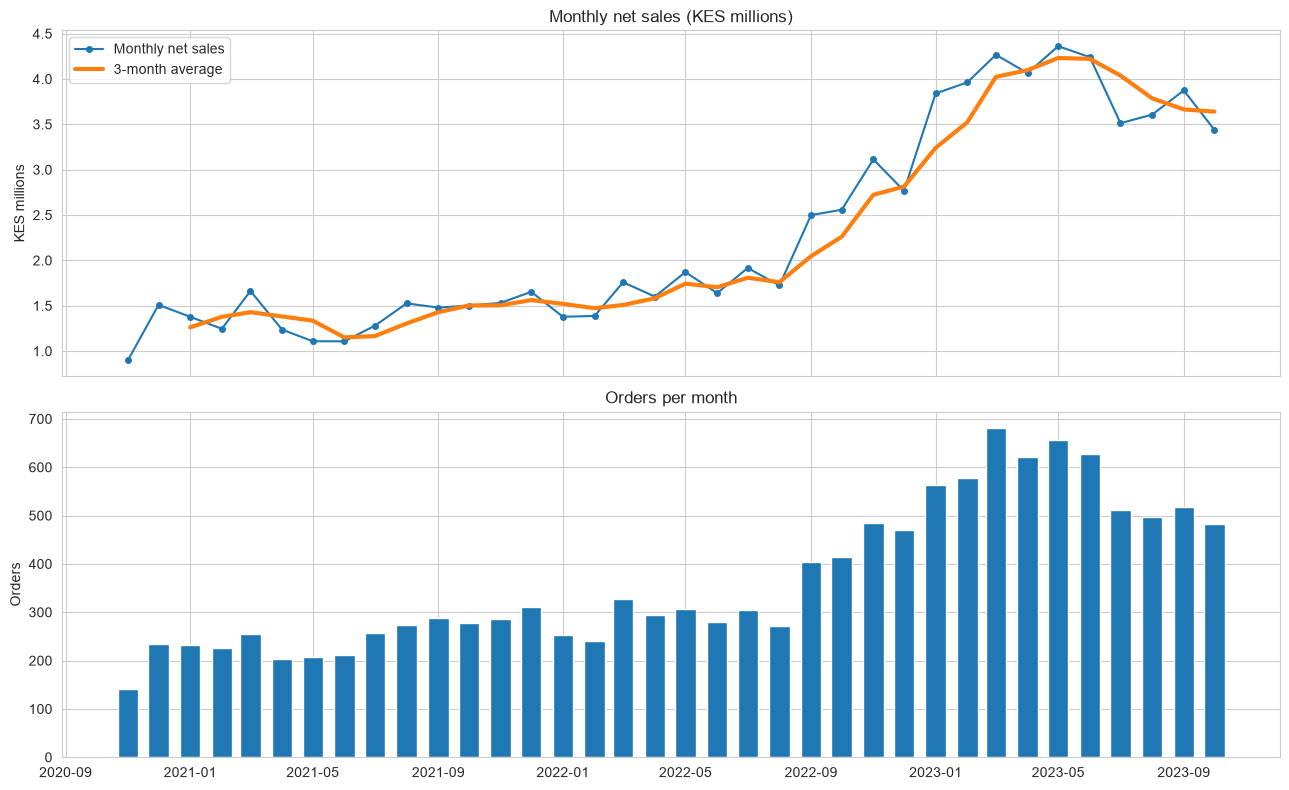

,net_sales_m,orders,sales_3m_avg
month,,,
2020-11-01,0.90,142,NaN
2020-12-01,1.51,235,NaN
2021-01-01,1.38,232,1.26


,net_sales_m,orders,sales_3m_avg
month,,,
2023-08-01,3.61,497,3.79
2023-09-01,3.87,518,3.66
2023-10-01,3.44,482,3.64


In [10]:
# Monthly net sales (all lines) and number of product orders
monthly = pd.DataFrame({
    "net_sales_m": eda.groupby("month")["net_sales"].sum() / 1e6,        # KES millions
    "orders":      items.groupby("month")["order_name"].nunique(),
}).fillna(0)
monthly["sales_3m_avg"] = monthly["net_sales_m"].rolling(3).mean()
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(monthly.index, monthly["net_sales_m"], marker="o", ms=4, label="Monthly net sales")
axes[0].plot(monthly.index, monthly["sales_3m_avg"], lw=3, label="3-month average")
axes[0].set(title="Monthly net sales (KES millions)", ylabel="KES millions")
axes[0].legend()

axes[1].bar(monthly.index, monthly["orders"], width=20)
axes[1].set(title="Orders per month", ylabel="Orders")
plt.tight_layout()
plt.show()

display(monthly.round(2).head(3)); display(monthly.round(2).tail(3))

Plots monthly net sales with a 3-month average, and the number of orders per month. In the saved run, monthly net sales rose from KES 0.90 million in November 2020 (a partial month) to KES 3.61, 3.87 and 3.44 million in August, September and October 2023, while orders per month rose from about 140 to between 480 and 520.

#### Yearly pattern (seasonality)

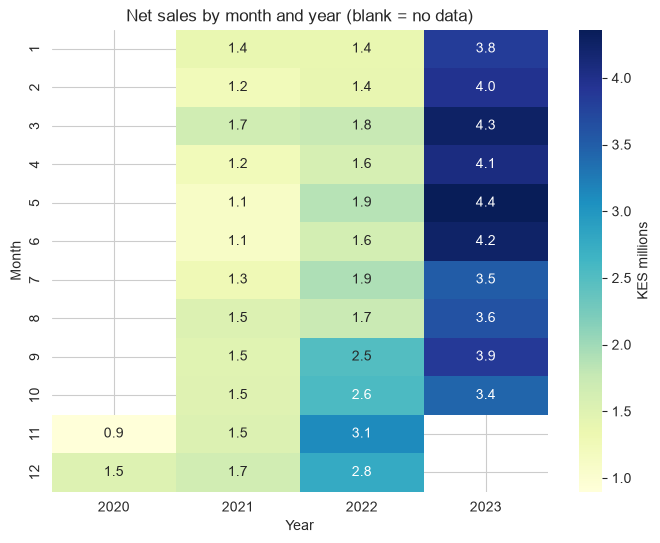

,Jan-Oct net sales (KES m),yoy_growth_pct
year,,
2021,13.5,NaN
2022,18.3,35.6
2023,39.2,114.2


In [11]:
# Net sales by calendar month and year (KES millions)
heat = eda.pivot_table(index="month_num", columns="year", values="net_sales", aggfunc="sum") / 1e6

plt.figure(figsize=(8, 6))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "KES millions"})
plt.title("Net sales by month and year (blank = no data)")
plt.ylabel("Month"); plt.xlabel("Year")
plt.show()

# Growth on a like-for-like basis: January to October of each full year
jan_oct = (eda[eda["month_num"] <= 10].groupby("year")["net_sales"].sum() / 1e6).round(1)
display(jan_oct.to_frame("Jan-Oct net sales (KES m)").assign(
    yoy_growth_pct=lambda t: (t.iloc[:, 0].pct_change() * 100).round(1)))

Shows net sales by calendar month and year as a heatmap and compares January to October across years, the only like-for-like months available in every year. The growth is very large (+35.6% in 2022 and +114.2% in 2023), so growth dominates the year-on-year comparison and any recurring seasonal pattern is hard to separate from it.

#### Channels and categories

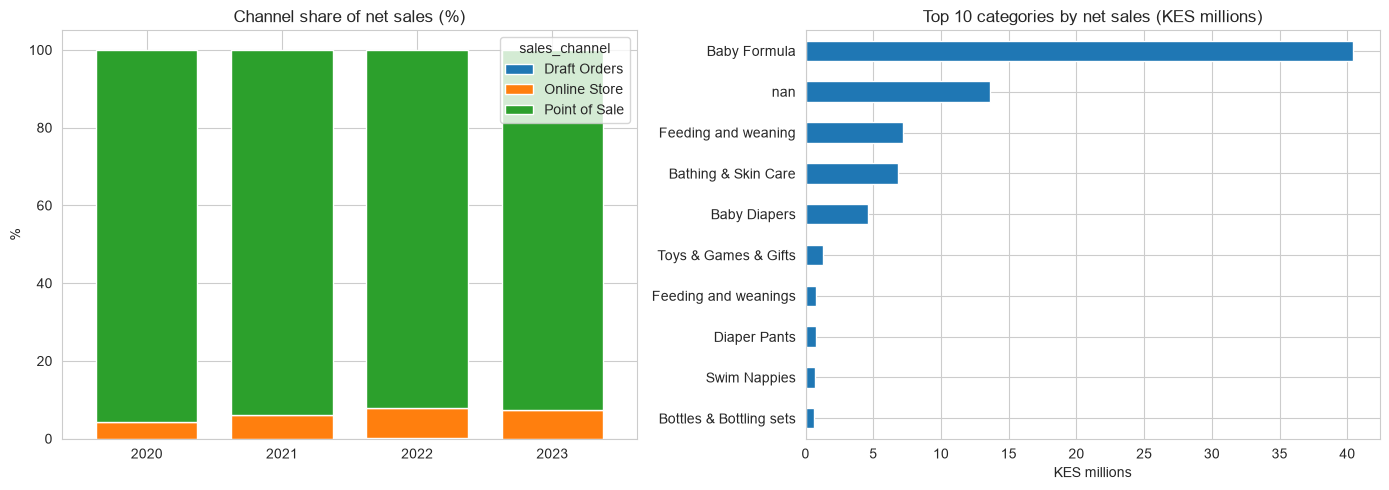

Product lines without a category: 5,936 (25.8%), carrying 16.6% of product net sales


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Channel share of net sales by year
ch = eda.pivot_table(index="year", columns="sales_channel", values="net_sales", aggfunc="sum")
(ch.div(ch.sum(axis=1), axis=0) * 100).plot(kind="bar", stacked=True, ax=axes[0], width=0.75)
axes[0].set(title="Channel share of net sales (%)", ylabel="%", xlabel="")
axes[0].tick_params(axis="x", rotation=0)

# Top product categories (labels trimmed so " Baby Diapers" and "Baby Diapers" merge)
cat = (items.assign(product_type=items["product_type"].str.strip())
            .groupby("product_type", dropna=False)["net_sales"].sum().sort_values(ascending=False))
(cat.head(10) / 1e6).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set(title="Top 10 categories by net sales (KES millions)", xlabel="KES millions", ylabel="")
plt.tight_layout(); plt.show()

# How much revenue has no category at all?
missing_cat = items["product_type"].isna()
print(f"Product lines without a category: {missing_cat.sum():,} "
      f"({missing_cat.mean():.1%}), carrying {items.loc[missing_cat, 'net_sales'].sum() / items['net_sales'].sum():.1%} of product net sales")

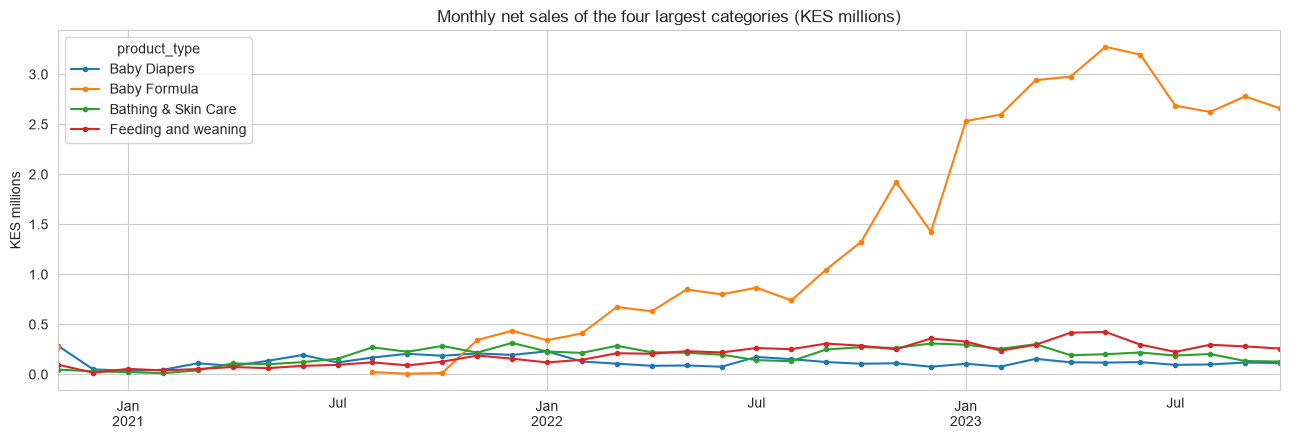

In [13]:
# Monthly net sales of the four largest categories (labels trimmed; sales without a category are skipped)
top4 = cat[cat.index.notna()].head(4).index
cat_month = (items.assign(product_type=items["product_type"].str.strip())
                  .loc[lambda d: d["product_type"].isin(top4)]
                  .pivot_table(index="month", columns="product_type", values="net_sales", aggfunc="sum") / 1e6)
cat_month.index = cat_month.index.to_timestamp()

ax = cat_month.plot(figsize=(13, 4.5), marker="o", ms=3)
ax.set(title="Monthly net sales of the four largest categories (KES millions)", ylabel="KES millions", xlabel="")
plt.tight_layout(); plt.show()

Shows channel shares by year, the ten largest categories, and how the four largest categories move month by month. About 25.8% of product lines have no category, carrying 16.6% of product net sales, so category series need careful preparation (Section 3.9).

#### Products and the "Rider" check

In [14]:
# Most frequently sold names in product lines, before removing riders
top = (prod.groupby("product")
           .agg(lines=("sale_id", "count"), net_sales=("net_sales", "sum"), is_rider=("is_rider", "max"))
           .sort_values("lines", ascending=False).head(15))
display(top)

rider = prod[prod["is_rider"]]
print(f"\nRider lines: {len(rider):,} | names: {sorted(rider['product'].unique())[:10]}")
print(f"Rider net sales: KES {rider['net_sales'].sum():,.0f} "
      f"({rider['net_sales'].sum() / prod['net_sales'].sum():.1%} of product-line sales)")

# How fragmented are the product names?
print(f"\nUnique product names: {items['product'].nunique():,}")
print(f"Names sold only once: {(items['product'].value_counts() == 1).sum():,}")

,lines,net_sales,is_rider
product,,,
Rider,1061,276907.31,True
Rider Rajab,848,223450.00,True
Rider Peter,790,221830.00,True
Aptamil Stage 2 Follow On Milk Powder 800g,710,3951300.00,False
Aptamil 2 Follow On Milk Powder 800G,611,4046500.00,False
Aptamil 1 First Baby Milk Formula from Birth 800g,562,3453076.52,False
Rajab,527,143690.00,False
Aptamil Stage 1 First Infant Milk Powder from Birth 800g,465,2808600.00,False
Peter,432,121070.00,False



Rider lines: 4,618 | names: ['Amos rider', 'Delivery (Rider Jeff )', 'Geofrey rider', 'Januari Bolt Rider', 'Jeff rider', 'Michael  rider', 'Rahab rider', 'Rajab Rider', 'Rajab rider', 'Rider']
Rider net sales: KES 1,228,413 (1.5% of product-line sales)

Unique product names: 1,836
Names sold only once: 525


Lists the most frequently sold names and checks for delivery-rider charges recorded as products. Names such as `Rider`, `Rider Rajab` and `Rider Peter` are delivery charges (4,618 product order lines match the word "rider"), and single-word names such as `Rajab` and `Peter` look like the same thing. They are revenue, so they stay in total net sales, but they are not merchandise.

#### Sales distributions

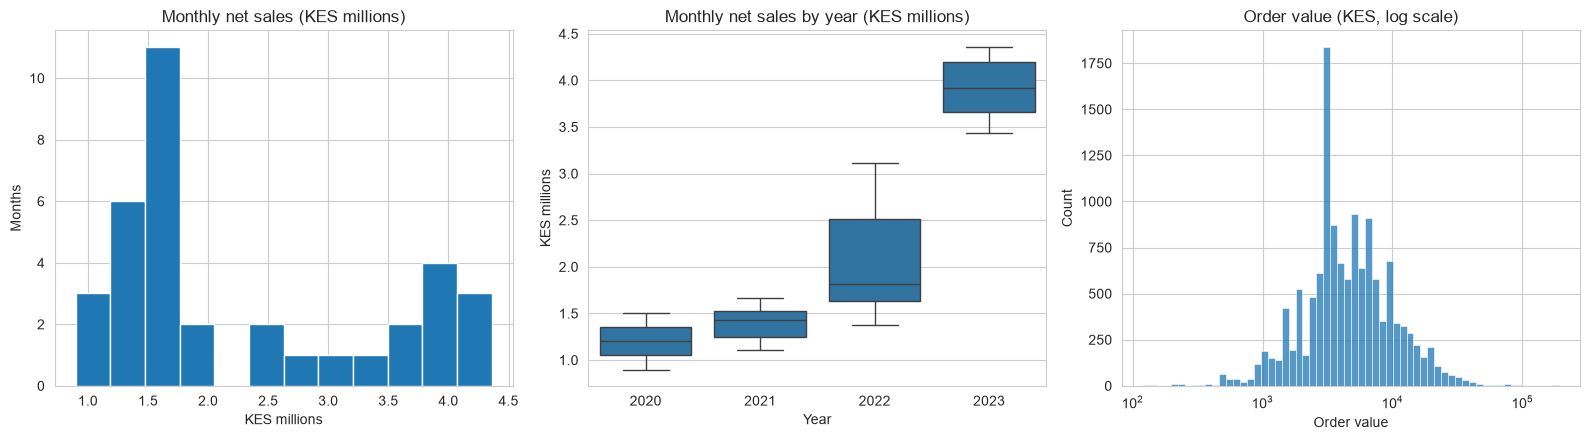

,monthly net sales (KES m)
count,36.00
mean,2.29
std,1.13
min,0.90
25%,1.46
50%,1.69
75%,3.46
max,4.36


,order value (KES)
count,13191.0
mean,6213.0
std,6890.0
min,120.0
50%,4200.0
90%,12600.0
99%,30400.0
max,192000.0


In [15]:
# Distribution of monthly net sales and of order values (genuine product lines only)
order_value = items.groupby("order_name")["net_sales"].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(monthly["net_sales_m"], bins=12)
axes[0].set(title="Monthly net sales (KES millions)", xlabel="KES millions", ylabel="Months")

sns.boxplot(x=monthly.index.year, y=monthly["net_sales_m"], ax=axes[1])
axes[1].set(title="Monthly net sales by year (KES millions)", xlabel="Year", ylabel="KES millions")

sns.histplot(order_value, bins=60, log_scale=True, ax=axes[2])
axes[2].set(title="Order value (KES, log scale)", xlabel="Order value")
plt.tight_layout(); plt.show()

display(monthly["net_sales_m"].describe().round(2).to_frame("monthly net sales (KES m)"))
display(order_value.describe(percentiles=[.5, .9, .99]).round(0).to_frame("order value (KES)"))

Shows how monthly net sales and order values are distributed. Monthly values are spread widely because sales trend upwards, so the yearly boxplots are more informative than the single histogram: each year sits at a clearly higher level than the last. Order values span a wide range, so they are plotted on a log scale.

#### Outliers and distributions

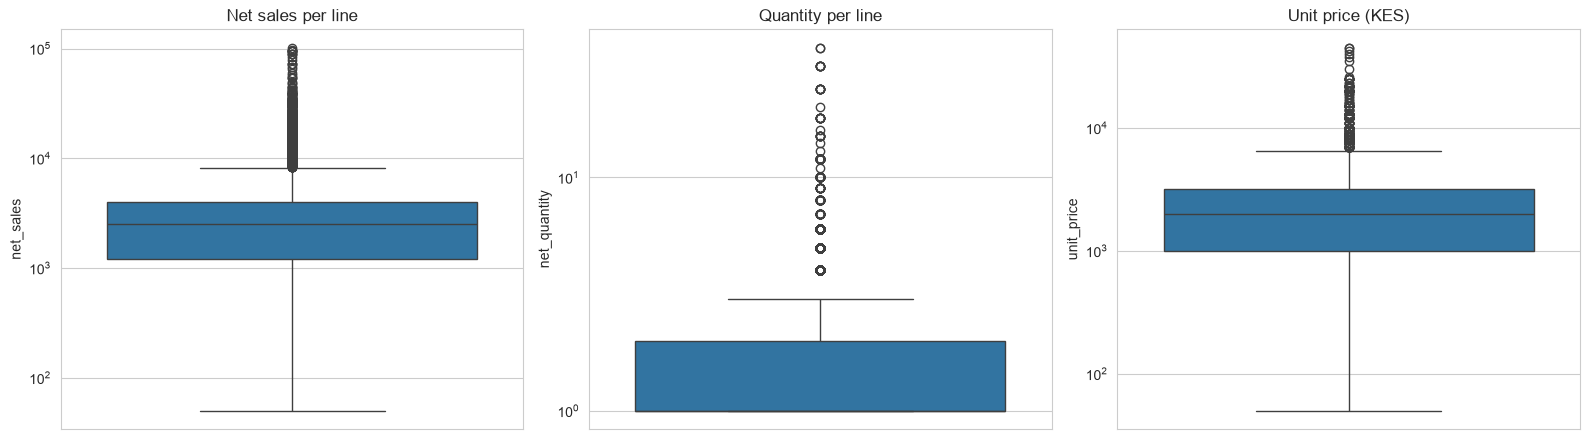

Lines above the IQR fence (KES 8,200): 2,017 (8.8%)


,order_name,product,net_quantity,net_sales
23164,TS11566,"Neocate Junior 400g, 1+Years",12,102000.0
18772,TS9437,Aptamil Stage 2 Follow On Milk Powder 800g (WH...,36,97200.0
15460,TS7893,Aptamil 2 Follow On Milk Powder 800G,30,96000.0
15461,TS7893,Aptamil 1 First Baby Milk Formula from Birth 800g,30,96000.0
16967,TS8590,Aptamil 1 First Baby Milk Formula from Birth 800g,30,96000.0
16968,TS8590,Aptamil 2 Follow On Milk Powder 800G,30,96000.0
17367,TS8782,Aptamil 1 First Baby Milk Formula from Birth 800g,30,96000.0
12932,TS6768,"Neocate Junior 400g, 1+Years",12,90000.0


Lines with quantity <= 0: 0
Lines with net_sales <= 0: 0


In [16]:
# Unit price implied by each line
items = items.assign(unit_price=items["gross_sales"] / items["net_quantity"].where(items["net_quantity"] > 0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(y=items["net_sales"], ax=axes[0]);          axes[0].set(title="Net sales per line", yscale="log")
sns.boxplot(y=items["net_quantity"], ax=axes[1]);       axes[1].set(title="Quantity per line", yscale="log")
sns.boxplot(y=items["unit_price"].dropna(), ax=axes[2]); axes[2].set(title="Unit price (KES)", yscale="log")
plt.tight_layout(); plt.show()

# IQR rule on net sales, applied only to report how many lines look extreme
q1, q3 = items["net_sales"].quantile([.25, .75])
upper = q3 + 1.5 * (q3 - q1)
print(f"Lines above the IQR fence (KES {upper:,.0f}): {(items['net_sales'] > upper).sum():,} "
      f"({(items['net_sales'] > upper).mean():.1%})")

# Inspect the largest lines and any zero, negative or odd quantities
display(items.nlargest(8, "net_sales")[["order_name", "product", "net_quantity", "net_sales"]])
print("Lines with quantity <= 0:", (items["net_quantity"] <= 0).sum())
print("Lines with net_sales <= 0:", (items["net_sales"] <= 0).sum())

Examines line-level outliers. The IQR fence flags 2,017 lines (8.8%), but the largest lines are bulk purchases of 12 to 36 units at the normal unit price (for example 30 tins of formula). There are no lines with zero or negative quantity or sales among product lines. Extreme lines are therefore treated as valid sales spikes and are not removed.

#### When customers buy, discounts and returns

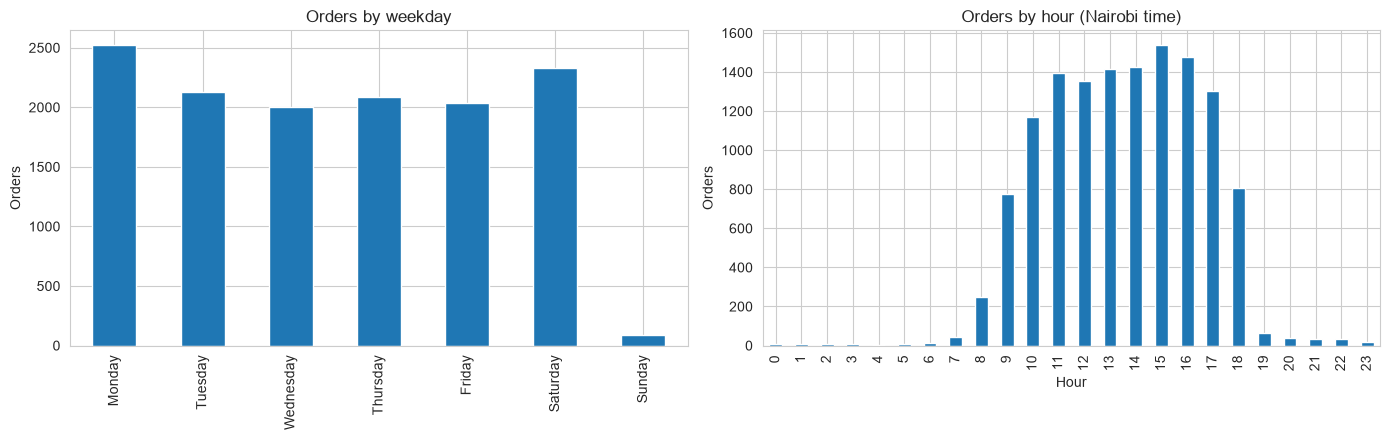

Discount rate (discounts / gross sales): 0.28%
Return lines: 317 | returns value: KES -689,647


,order_name,product,net_quantity,returns,net_sales
5,TS1014,Aptamil 1 First Baby Milk Formula from Birth 800g,-1,-3000,-3000.0
64,TS1039,Rider,-1,-700,-700.0
152,TS1018,Mamia Ultra Dry Junior Size 5-72 Nappies (11-2...,-1,-2500,-2500.0
237,TS1094,NaN,0,3400,3400.0
238,TS1094,Aptamil Anti-Reflux,-1,-3400,-3400.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Orders by weekday (Nairobi time)
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
wk = items.drop_duplicates("order_name")["weekday"].value_counts().reindex(days)
wk.plot(kind="bar", ax=axes[0]); axes[0].set(title="Orders by weekday", xlabel="", ylabel="Orders")

# Orders by hour of day
items.drop_duplicates("order_name")["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set(title="Orders by hour (Nairobi time)", xlabel="Hour", ylabel="Orders")
plt.tight_layout(); plt.show()

# Discounts and returns, using product lines of both sale types
all_prod = eda[eda["transaction_type"] == "product"]
print(f"Discount rate (discounts / gross sales): {all_prod['discounts'].abs().sum() / all_prod['gross_sales'].sum():.2%}")
ret = eda[eda["sale_type"] == "return"]
print(f"Return lines: {len(ret):,} | returns value: KES {ret['net_sales'].sum():,.0f}")
display(ret[["order_name", "product", "net_quantity", "returns", "net_sales"]].head())

Shows sales timing by weekday and hour (Nairobi time), the discount rate and the return lines. Discounts are 0.28% of gross sales, and 317 return lines total KES -689,647. Returns are small relative to sales but real, so they remain in the net sales target.

### 2.5 Initial Findings Relevant to Forecasting

- **Trend:** sales grew strongly through the period. January to October net sales rose from KES 13.5 million (2021) to KES 18.3 million (2022, +35.6%) and KES 39.2 million (2023, +114.2%). A forecasting method must handle a strong upward trend.
- **Seasonality:** only three yearly cycles are available, the first starting with a partial month, and the growth is much larger than any calendar pattern visible in the heatmap. Recurring seasonality cannot be confirmed from this data, so non-seasonal and seasonal methods are both tested in Phase 4.
- **Channels and categories:** the point of sale accounts for about 89% of lines. Baby formula dominates category sales (Section 3.14), and about a quarter of product lines have no category.
- **Outliers and unusual periods:** large lines are valid bulk orders at normal prices and are kept. Month-level checks for unusual periods are done in Section 3.13.
- **Data issues to fix in Phase 3:** delivery-rider charges recorded as product lines, inconsistent product names, missing and near-duplicate category labels, UTC timestamps and the partial first month.
- **Context versus evidence:** the data confirms 36 months of sales of baby-care products, but not the country or the currency. Those come from the project brief.

## 3. Data Preparation

The raw table is turned into clean, validated datasets for forecasting: a complete monthly series of total net sales, a month-by-category series and a set of leakage-safe time-series features. The original `df` is never modified. All work happens on a separate copy called `clean`, and an audit log records the number of rows, orders and total net sales after every step, so any unexpected loss of data is caught immediately.

### 3.1 Working Copy and Audit Log

All preparation happens on `clean`, a copy of `df`. The raw totals are stored so that every later output can be reconciled to them. The audit log records rows, orders and net sales after each step, so any loss or change of data is visible immediately.

In [18]:
# Separate working copy: the raw df is never modified from here on.
clean = df.copy()

# Reference totals from the raw table, used later to reconcile every output.
RAW_ROWS = len(df)
RAW_ORDERS = df["order_name"].nunique()
RAW_NET_SALES = df["net_sales"].sum()
RAW_COLUMNS = list(df.columns)

# Audit log: one record per preparation step.
audit_rows = []

def log_step(step, frame=None, *, kind="pipeline", rows=None, orders=None,
             net_sales=None, note=""):
    """Append rows, orders and net sales for a step to the audit log."""
    if frame is not None:
        rows = len(frame) if rows is None else rows
        orders = frame["order_name"].nunique() if orders is None else orders
        net_sales = frame["net_sales"].sum() if net_sales is None else net_sales
    audit_rows.append({"Step": step, "Kind": kind, "Rows": rows, "Orders": orders,
                       "Net Sales": net_sales, "Note": note})

log_step("0. Raw data (df)", df, note="Baseline loaded from PostgreSQL")
log_step("1. Working copy (clean)", clean, note="Copy only, nothing changed")
display(pd.DataFrame(audit_rows).drop(columns="Kind"))

,Step,Rows,Orders,Net Sales,Note
0,0. Raw data (df),28755,13257,82498808.06,Baseline loaded from PostgreSQL
1,1. Working copy (clean),28755,13257,82498808.06,"Copy only, nothing changed"


`clean` is an exact copy of `df`, and the first two audit rows are identical, which confirms nothing has changed yet. `RAW_*` holds the reference totals for the final reconciliation, and `log_step()` is called after each transformation.

### 3.2 Standardizing Time to Nairobi (Africa/Nairobi)

Timestamps are stored in UTC, but the business trades in Nairobi time (UTC+3). A sale made at 00:30 on 1 February in Nairobi is stored as 21:30 UTC on 31 January, so it would fall into the wrong month if months were built from UTC. Months must therefore be built from local time. This belongs in Data Preparation because it changes the aggregation key of the forecasting target. Only the calendar fields needed for aggregation are created (weekday and hour were EDA-only).

In [19]:
# Convert UTC timestamps to Nairobi time before extracting any calendar field.
clean["date_local"] = pd.to_datetime(clean["date"], utc=True).dt.tz_convert("Africa/Nairobi")
local_naive = clean["date_local"].dt.tz_localize(None)        # keep local clock time

clean["date_nbo"]   = local_naive.dt.normalize()              # Nairobi calendar date
clean["month"]      = local_naive.dt.to_period("M")           # aggregation key (as in the EDA)
clean["year"]       = local_naive.dt.year
clean["month_num"]  = local_naive.dt.month
clean["quarter"]    = local_naive.dt.quarter
clean["year_month"] = clean["month"].astype(str)

# How many lines would have landed in a different month if UTC had been used?
utc_month = clean["date"].dt.tz_convert("UTC").dt.tz_localize(None).dt.to_period("M")
shifted = utc_month != clean["month"]
print(f"Lines whose month changes after conversion: {shifted.sum():,} "
      f"({shifted.mean():.2%}) | net sales moved: KES {clean.loc[shifted, 'net_sales'].sum():,.0f}")

# Coverage check on the local calendar.
EXPECTED_MONTHS = 36                                          # Nov 2020 - Oct 2023 (scope in 1.7)
n_months = len(pd.period_range(clean["month"].min(), clean["month"].max(), freq="M"))
print(f"Local date range: {clean['date_nbo'].min().date()} -> {clean['date_nbo'].max().date()} | months spanned: {n_months}")
assert n_months == EXPECTED_MONTHS, f"Expected {EXPECTED_MONTHS} months, found {n_months}"

log_step("2. Nairobi time and calendar fields", clean, note="Columns added, no rows changed")

Lines whose month changes after conversion: 2 (0.01%) | net sales moved: KES 3,400
Local date range: 2020-11-11 -> 2023-10-31 | months spanned: 36


The code added Nairobi-local date, month, year, month number, quarter and `year_month`. The first printed line shows how many lines and how much revenue would have been assigned to the wrong month under UTC. These are the lines (typically evening sales on the last day of a month) that the conversion corrects. The assertion confirms the data still spans exactly 36 months, so the monthly series built in 3.12 has the expected length.

### 3.3 Duplicate Record Review

Section 2.2 found no duplicate `sale_id` values and no fully duplicated rows. Before deciding whether anything needs removing, we separate technical duplicates (the same database record loaded twice) from legitimate repeats (the same product on several lines of one order). Only the first kind would be removed.

In [20]:
# Technical duplicates: identical sale IDs or identical rows would be database duplicates.
assert clean["sale_id"].is_unique, "sale_id must be unique"
print("Duplicate sale_id        :", clean["sale_id"].duplicated().sum())
print("Fully duplicated rows    :", clean.duplicated(subset=RAW_COLUMNS).sum())

# Order identity: order_name should map to one order_id and vice versa.
print("order_name -> several order_id:", (clean.groupby("order_name")["order_id"].nunique() > 1).sum())
print("order_id -> several order_name:", (clean.groupby("order_id")["order_name"].nunique() > 1).sum())

# Business-level repeats: the same product more than once inside one order.
order_lines = clean[clean["sale_type"] == "order"]
same_item = order_lines.duplicated(["order_name", "product"], keep=False) & order_lines["product"].notna()
print(f"Order lines sharing order_name + product: {same_item.sum():,} "
      f"(in {order_lines.loc[same_item, 'order_name'].nunique():,} orders)")

# Lines identical to another line apart from sale_id.
business_cols = [c for c in RAW_COLUMNS if c != "sale_id"]
lookalikes = clean.duplicated(subset=business_cols, keep=False)
print(f"Lines identical to another line apart from sale_id: {lookalikes.sum():,}")
display(order_lines.loc[same_item, ["order_name", "sale_id", "date", "product", "net_quantity", "net_sales"]]
        .sort_values(["order_name", "product"]).head(6))

log_step("3. Duplicate review", clean, note="No rows removed: sale_id unique, no exact duplicates")

Duplicate sale_id        : 0
Fully duplicated rows    : 0
order_name -> several order_id: 0
order_id -> several order_name: 0
Order lines sharing order_name + product: 321 (in 142 orders)
Lines identical to another line apart from sale_id: 300


,order_name,sale_id,date,product,net_quantity,net_sales
30,TS1025,8756546142360,2020-11-17 11:56:10+00:00,Tommee Tippee Advanced Anti-Colic Teats 2pk,1,1500.0
32,TS1025,8756546076824,2020-11-17 11:56:10+00:00,Tommee Tippee Advanced Anti-Colic Teats 2pk,1,1500.0
20703,TS10386,16427917115647,2023-04-01 15:12:23+00:00,Munchkin Colour Me Hungry Splash Dining Set,1,3500.0
20704,TS10386,16427917148415,2023-04-01 15:12:23+00:00,Munchkin Colour Me Hungry Splash Dining Set,1,3500.0
21587,TS10810,16489659072767,2023-04-22 08:37:46+00:00,"Tommee Tippee Superstar Training Straw Cup, 6+...",1,1600.0
21588,TS10810,16489659039999,2023-04-22 08:37:46+00:00,"Tommee Tippee Superstar Training Straw Cup, 6+...",1,1600.0


In [21]:
# Quantify the lookalike lines: identical in every field except sale_id.
lk = clean[lookalikes].copy()
lk["copy_no"] = lk.groupby(business_cols, dropna=False).cumcount()
extra = lk[lk["copy_no"] > 0]          # 2nd and later copies = what removal would delete

print(f"Lookalike groups: {lk.groupby(business_cols, dropna=False).ngroups:,} | extra copies: {len(extra):,} | "
      f"net sales in extra copies: KES {extra['net_sales'].sum():,.0f} "
      f"({extra['net_sales'].sum() / clean['net_sales'].sum():.2%} of all net sales)")
display(extra.groupby(["transaction_type", "sale_type", "sales_channel"])
        .agg(lines=("sale_id", "count"), net_sales=("net_sales", "sum")))
display(extra["net_quantity"].value_counts().head(5).to_frame("lines"))

Lookalike groups: 145 | extra copies: 155 | net sales in extra copies: KES 215,531 (0.26% of all net sales)


lines  net_sales
transaction_type sale_type sales_channel                  
product          order     Online Store      22    30650.0
                           Point of Sale    129   188430.6
                 return    Online Store       2    -2000.0
                           Point of Sale      2    -1550.0

,lines
net_quantity,
1,149
-1,4
2,1
4,1


Sale_id is unique and no row is an exact copy, so there are no technical duplicates. However, about 300 lines are identical to another line in every field except `sale_id`, including the timestamp. The `sale_id` values differ, which suggests separate scanned or added line items rather than a double load. This cannot be proven from the data. All lines are therefore kept, and the table above sizes the exposure: it shows the value that would be removed from the monthly target if these were duplicates. Confirm with the retailer whether the point of sale records one line per scanned unit.

### 3.4 Numeric Validation

Negative values are not errors in this data: returns and adjustments are stored with negative quantities and values. Validation therefore checks whether each sign is *consistent with the line type* instead of deleting negatives. The two accounting identities from 2.2 are re-asserted as a regression guard.

In [22]:
num_cols = ["net_quantity", "gross_sales", "discounts", "returns",
            "net_sales", "shipping", "taxes", "total_sales"]

# Data types and nulls for the numeric fields.
assert clean[num_cols].notna().all().all(), "Unexpected nulls in numeric columns"
assert all(pd.api.types.is_numeric_dtype(clean[c]) for c in num_cols)

# Sign profile per column.
sign_profile = pd.DataFrame({
    "negative": (clean[num_cols] < 0).sum(),
    "zero":     (clean[num_cols] == 0).sum(),
    "positive": (clean[num_cols] > 0).sum(),
    "min":      clean[num_cols].min(),
    "max":      clean[num_cols].max(),
})
display(sign_profile)

# Business rules: what should hold for each kind of line.
is_order  = clean["sale_type"] == "order"
is_return = clean["sale_type"] == "return"
is_prod   = clean["transaction_type"] == "product"
rules = {
    "order lines with quantity <= 0 (product)":    (is_order & is_prod & (clean["net_quantity"] <= 0)).sum(),
    "order lines with net_sales < 0 (product)":    (is_order & is_prod & (clean["net_sales"] < 0)).sum(),
    "order lines with gross_sales == 0 (product)": (is_order & is_prod & (clean["gross_sales"] == 0)).sum(),
    "order lines carrying a return value":         (is_order & (clean["returns"] != 0)).sum(),
    "return lines with quantity > 0":              (is_return & (clean["net_quantity"] > 0)).sum(),
    "return lines with positive net_sales":        (is_return & (clean["net_sales"] > 0)).sum(),
    "discounts > 0 (should be <= 0)":              (clean["discounts"] > 0).sum(),
}
display(pd.Series(rules, name="lines").to_frame())

# Regression guard: the two accounting identities found in 2.2 still hold.
assert ((clean["net_sales"] + clean["shipping"] + clean["taxes"] - clean["total_sales"]).abs() <= 0.01).all()
assert ((clean["gross_sales"] + clean["discounts"] + clean["returns"] - clean["net_sales"]).abs() <= 0.01).all()

log_step("4. Numeric validation", clean, note="Checks only: negatives kept as returns/adjustments")

,negative,zero,positive,min,max
net_quantity,235,910,27610,-12.0,36.0
gross_sales,0,1147,27608,0.0,102000.0
discounts,178,28577,0,-16200.0,0.0
returns,235,28503,17,-38400.0,8500.0
net_sales,235,895,27625,-38400.0,102000.0
shipping,65,27862,828,-800.0,800.0
taxes,1,28711,43,-112.0,1600.0
total_sales,300,2,28453,-38400.0,102000.0


,lines
order lines with quantity <= 0 (product),0
order lines with net_sales < 0 (product),0
order lines with gross_sales == 0 (product),0
order lines carrying a return value,0
return lines with quantity > 0,0
return lines with positive net_sales,17
discounts > 0 (should be <= 0),0


All numeric columns are complete and numeric. The sign profile shows that negatives come from returns and discounts, as expected. The rule table counts the lines that break a business rule. Product order lines should have positive quantities and values (the EDA found none that do not). Any non-zero count in the return-line rows is an adjustment worth noting, such as the zero-quantity, positive-value line seen for TS1094. Nothing is removed here, because return and adjustment lines are legitimate and must stay in the net sales target.

### 3.5 Missing-Value Review and Treatment Plan

Only `product` and `product_type` contain gaps. Because the meaning of a missing value depends on the line type (a shipping line has no product by nature), the gaps are profiled by `transaction_type` and `sale_type` first. Each decision is then tied to the variable's meaning instead of blanket imputation.

In [23]:
# Missing values per column (only columns with gaps), and where the gaps sit.
missing = clean.isna().sum()
missing = missing[missing > 0]
print("Columns with missing values:", dict(missing))
assert set(missing.index) <= {"product", "product_type"}, "Unexpected gaps outside product / product_type"

# Missing product names by line type: shipping/unknown lines are expected to have none.
display(clean.assign(no_product=clean["product"].isna())
             .groupby(["transaction_type", "sale_type"])
             .agg(lines=("sale_id", "count"), no_product=("no_product", "sum"),
                  net_sales=("net_sales", "sum")).query("no_product > 0"))

# Placeholder strings that behave like missing values.
placeholders = {"", "nan", "none", "null", "n/a", "na", "-"}
for col in ["product", "product_type"]:
    print(f"{col}: placeholder strings = {clean[col].str.strip().str.casefold().isin(placeholders).sum():,}")

# Treatment plan, applied in the sections that follow.
treatment = pd.DataFrame({
    "column": ["product", "product_type", "all other columns"],
    "missing": [clean["product"].isna().sum(), clean["product_type"].isna().sum(), 0],
    "decision": [
        "Keep NaN. Lines stay in the forecasting totals; they carry no product identity.",
        "Recover only when the same product has exactly one known category; otherwise label 'Unknown'.",
        "Complete: no treatment needed.",
    ],
})
display(treatment)

log_step("5. Missing-value review", clean, note="Profile only: treatment applied in 3.6 and 3.9")

Columns with missing values: {'product_type': np.int64(11511), 'product': np.int64(910)}


lines  no_product  net_sales
transaction_type sale_type                              
shipping         order        828         828        0.0
                 return        65          65        0.0
unknown          return        17          17    65497.0

product: placeholder strings = 0
product_type: placeholder strings = 0


,column,missing,decision
0,product,910,Keep NaN. Lines stay in the forecasting totals...
1,product_type,11511,Recover only when the same product has exactly...
2,all other columns,0,Complete: no treatment needed.


Only `product` and `product_type` have gaps. All 910 missing product names belong to shipping lines (893) and unknown-type lines (17), and none are on genuine product sales, so no product name is imputed. The 11,511 missing categories are handled by recovery or an explicit `Unknown` label in 3.9.

### 3.6 Product Name Standardization

Names are cleaned conservatively: repeated whitespace is collapsed, leading/trailing spaces are stripped, placeholders become missing, and spellings that differ only by letter case are unified. A safety check makes sure case-folding never merges names that carry *different* categories. Deeper fragmentation (for example `Aptamil Stage 2 ...` vs `Aptamil 2 ...`) cannot be resolved reliably from the data, so no mapping is invented. Those names are listed for a future business-rule step.

In [24]:
# Safe text cleaning: collapse repeated spaces, trim, and turn placeholders into missing.
p = clean["product"].str.replace(r"\s+", " ", regex=True).str.strip()
p = p.mask(p.str.casefold().isin(placeholders))

clean["product_clean"] = p
clean["product_key"]   = p.str.casefold()        # case-insensitive matching key

print(f"Missing names     : {clean['product'].isna().sum():,} -> {clean['product_clean'].isna().sum():,}")
print(f"Unique raw names  : {clean['product'].nunique():,}")
print(f"After whitespace  : {p.nunique():,}")
print(f"After case-fold   : {clean['product_key'].nunique():,}")

# Merge-safety check: do names that differ only by case ever carry different categories?
groups = (clean.dropna(subset=["product_key"]).groupby("product_key")
          .agg(variants=("product_clean", "nunique"),
               categories=("product_type", lambda s: s.dropna().str.strip().nunique())))
merged = groups[groups["variants"] > 1]
risky = merged[merged["categories"] > 1]
print(f"Keys merged from several spellings: {len(merged):,} | with conflicting categories: {len(risky):,}")

# Use the most frequent spelling as the display name, except for risky keys.
canon = (clean.dropna(subset=["product_key"]).groupby("product_key")["product_clean"]
         .agg(lambda s: s.value_counts().idxmax()))
safe = clean["product_key"].notna() & ~clean["product_key"].isin(risky.index)
clean.loc[safe, "product_clean"] = clean.loc[safe, "product_key"].map(canon)

# Remaining fragmentation (for example "Aptamil Stage 2" versus "Aptamil 2") is not merged,
# because it cannot be resolved reliably from the data. Category series do not depend on it.

log_step("6. Product names standardized", clean, note="Whitespace/case only; no manual mapping invented")

Missing names     : 910 -> 910
Unique raw names  : 1,923
After whitespace  : 1,921
After case-fold   : 1,887
Keys merged from several spellings: 28 | with conflicting categories: 0


The cleaned name is stored in `product_clean` and the matching key in `product_key`; the raw `product` is untouched. The printed counts show how much fragmentation whitespace and case alone removed. "Keys merged" counts names that were unified, and "conflicting categories" should be 0: if it is not, those keys keep their original spelling and need review. Name variants that differ in wording (for example `Aptamil Stage 2` versus `Aptamil 2`) are not merged. This does not affect the monthly or category series, which do not depend on product names beyond the rider rule and category recovery.

### 3.7 Rider and Delivery Charge Handling

Delivery charges are recorded as product lines and are flagged rather than deleted because they contribute to total net sales but do not represent merchandise. The identification process follows two rules: first, product names containing the word rider are flagged during Exploratory Data Analysis (EDA); second, an evidence-based extension identifies single-word names, such as Rajab or Peter, that also appear in flagged rider names. These additional candidates are presented for review to ensure accurate classification. The TREAT_NAME_ONLY_AS_RIDER switch allows the business to disable this extension if it does not agree with the classification approach.

In [25]:
RIDER_RE = r"\brider\b"                          # same rule as the EDA
EDA_RIDER_LINES = 4_618                          # rider lines reported in 2.3 (product order lines)

# Rule 1: the word "rider" in the product name.
is_rider_regex = clean["product_clean"].str.contains(RIDER_RE, case=False, na=False)
eda_scope = (clean["transaction_type"] == "product") & (clean["sale_type"] == "order")
assert (is_rider_regex & eda_scope).sum() == EDA_RIDER_LINES, "Rider count differs from the EDA"

# Rule 2 (evidence-based): single-word names that equal a word used in a flagged rider name.
rider_words = (clean.loc[is_rider_regex, "product_key"].str.findall(r"[a-z]+")
               .explode().dropna().unique())
name_only = (~is_rider_regex
             & (clean["transaction_type"] == "product")
             & clean["product_key"].str.fullmatch(r"[a-z]+", na=False)
             & clean["product_key"].isin(rider_words))

# Review the name-only candidates before trusting them.
display(clean[name_only].groupby("product_clean")
        .agg(lines=("sale_id", "count"), net_sales=("net_sales", "sum"),
             median_price=("gross_sales", "median"),
             with_category=("product_type", lambda s: s.notna().sum()))
        .sort_values("lines", ascending=False).head(10))

TREAT_NAME_ONLY_AS_RIDER = True                  # set False to keep these lines as products
clean["is_rider"] = is_rider_regex | (name_only & TREAT_NAME_ONLY_AS_RIDER)

# Impact: rows and value flagged, by line type.
flagged = clean[clean["is_rider"]]
display(flagged.groupby(["transaction_type", "sale_type"])
        .agg(lines=("sale_id", "count"), net_sales=("net_sales", "sum")))
print(f"Flagged: {len(flagged):,} lines | net sales KES {flagged['net_sales'].sum():,.0f} "
      f"({flagged['net_sales'].sum() / clean['net_sales'].sum():.2%} of all net sales)")

# Before / after on product order lines (merchandise sales only).
before = clean[eda_scope]
after = before[~before["is_rider"]]
display(pd.DataFrame({"rows": [len(before), len(after)],
                      "orders": [before["order_name"].nunique(), after["order_name"].nunique()],
                      "products": [before["product_clean"].nunique(), after["product_clean"].nunique()],
                      "net_sales": [before["net_sales"].sum(), after["net_sales"].sum()]},
                     index=["with riders", "riders removed"]))

log_step("7. Rider charges flagged", clean, note="Flagged in is_rider, not deleted; kept in total net sales")

,lines,net_sales,median_price,with_category
product_clean,,,,
Rajab,530,144160.00,250.0,0
Peter,433,120770.00,250.0,0
Fargo,195,89215.00,460.0,0
Bus,161,44836.89,200.0,0
Delivery,130,35330.00,200.0,0
George,112,32750.00,300.0,0
Francis,107,28200.00,250.0,0
Barak,74,19070.00,250.0,0
Swahili,52,12220.00,225.0,0


lines   net_sales
transaction_type sale_type                   
product          order       6599  1805244.64
                 return         6    -2400.00

Flagged: 6,605 lines | net sales KES 1,802,845 (2.19% of all net sales)


,rows,orders,products,net_sales
with riders,27608,13255,1886,83188455.06
riders removed,21009,13158,1798,81383210.42


The assertion confirms that Rule 1 reproduces the EDA exactly (4,618 product order lines), so the name cleaning did not change the rider logic. The candidate table shows the extra name-only lines: a low median price (KES 200 to 460) and no category support treating them as delivery charges, but **confirm this with the business**. In total 6,605 lines are flagged, carrying KES 1.80 million or 2.19% of all net sales. For forecasting, rider lines stay inside total net sales (they are real revenue, and removing them would break reconciliation) and are reported as their own component in 3.12. The before and after table shows the merchandise pool without them.

### 3.8 Transaction Classification and Filtering Rules

Every line is assigned to exactly one `line_class`. This one column defines, in a single place, which lines feed each forecasting dataset. The total target keeps every class so it reconciles to the source. The category series keeps product sales and product returns, because only those lines carry a category.

In [26]:
tt, st = clean["transaction_type"], clean["sale_type"]

# One class per line; the order of conditions sets the priority.
conditions = [tt.eq("shipping"), tt.eq("gift_card"), tt.eq("unknown"),
              tt.eq("product") & clean["is_rider"],
              tt.eq("product") & st.eq("return"),
              tt.eq("product") & st.eq("order")]
classes = ["shipping_line", "gift_card", "unknown_type", "rider_charge", "product_return", "product_sale"]
clean["line_class"] = np.select(conditions, classes, default="other")
assert (clean["line_class"] != "other").all(), "Some lines were not classified"

# Which classes feed which dataset.
usage = pd.DataFrame({
    "in_forecast_total":  True,
    "in_category_series": [c in ("product_sale", "product_return") for c in classes],
}, index=classes)

summary = (clean.groupby("line_class")
           .agg(lines=("sale_id", "count"), orders=("order_name", "nunique"), net_sales=("net_sales", "sum"))
           .reindex(classes).join(usage))
display(summary)

log_step("8. Line classification", clean, note="Rules per dataset defined; no rows removed")

,lines,orders,net_sales,in_forecast_total,in_category_series
line_class,,,,,
shipping_line,893,828,0.00,True,False
gift_card,2,2,0.00,True,False
unknown_type,17,17,65497.00,True,False
rider_charge,6605,6368,1802844.64,True,False
product_return,229,175,-752744.00,True,True
product_sale,21009,13158,81383210.42,True,True


The assertion proves every line has a class. The table shows lines, orders and net sales per class together with its role. In the saved run the classes were 21,009 product-sale lines (KES 81.4 million), 6,605 rider-charge lines (KES 1.80 million), 229 product-return lines (KES -0.75 million), 893 shipping lines (KES 0), 17 unknown-type lines (KES 0.07 million) and 2 gift-card lines (KES 0). All classes feed the total net sales target, and only product sales and product returns feed the category series. No rows are removed, so the audit stays unchanged.

### 3.9 Product Category Preparation

Category labels are trimmed and unified by case, and are meaningful only for product lines. For missing categories, a value is recovered **only when the same product has exactly one known category elsewhere in the data**. This is a lookup of the retailer's own labelling, not an estimate. Everything else is labelled `Unknown`, so no category is invented. The `category_source` column records how each label was obtained.

In [27]:
is_prod = clean["line_class"].isin(["product_sale", "product_return"])

# Safe text cleaning, then one display label per case-insensitive key.
c = clean["product_type"].str.replace(r"\s+", " ", regex=True).str.strip()
c = c.mask(c.str.casefold().isin(placeholders))
clean["category_key"] = c.str.casefold()
canon_cat = (pd.DataFrame({"key": clean["category_key"], "label": c}).dropna()
             .groupby("key")["label"].agg(lambda s: s.value_counts().idxmax()))
clean["category_clean"] = clean["category_key"].map(canon_cat)
print(f"Category labels: raw {clean['product_type'].nunique()} -> clean {clean['category_clean'].nunique()}")

# Categories only make sense for product lines.
clean.loc[~is_prod, "category_clean"] = np.nan
clean["category_source"] = np.select([~is_prod, clean["category_clean"].notna()],
                                     ["not_applicable", "original"], default="missing")

def category_report(label, source):
    m = clean["category_source"].eq(source)
    base = clean.loc[is_prod, "net_sales"].sum()
    print(f"{label}: {m.sum():,} product lines ({m.sum() / is_prod.sum():.1%}) | "
          f"{clean.loc[m, 'net_sales'].sum() / base:.1%} of product net sales")

category_report("Missing category BEFORE recovery", "missing")

# Recover a category only when a product has exactly one known category in the data.
known = clean[is_prod & clean["category_clean"].notna() & clean["product_key"].notna()]
lookup = known.groupby("product_key")["category_clean"].agg(n="nunique", cat="first")
unambiguous = lookup.loc[lookup["n"] == 1, "cat"]

fill = clean["category_source"].eq("missing") & clean["product_key"].map(unambiguous).notna()
clean.loc[fill, "category_clean"] = clean.loc[fill, "product_key"].map(unambiguous)
clean.loc[fill, "category_source"] = "recovered_from_product"

# Everything still missing gets a transparent label instead of a guess.
still = clean["category_source"].eq("missing")
clean.loc[still, "category_clean"] = "Unknown"
clean.loc[still, "category_source"] = "unknown"

print(f"Recovered from the product's own known category: {fill.sum():,} lines")
category_report("Labelled 'Unknown' AFTER recovery", "unknown")
display(clean.loc[is_prod].groupby("category_source")
        .agg(lines=("sale_id", "count"), net_sales=("net_sales", "sum")))

log_step("9. Categories standardized", clean, note="Unambiguous recovery plus 'Unknown'; no guessed categories")

Category labels: raw 100 -> clean 90
Missing category BEFORE recovery: 3,996 product lines (18.8%) | 16.0% of product net sales
Recovered from the product's own known category: 2,552 lines
Labelled 'Unknown' AFTER recovery: 1,444 product lines (6.8%) | 4.0% of product net sales


,lines,net_sales
category_source,,
original,17242,67708300.21
recovered_from_product,2552,9695867.13
unknown,1444,3226299.08


Category labels fall from 100 to 90 once spacing and case are unified. Before recovery, 18.8% of product lines (16.0% of product net sales) had no category. Recovery from each product's own single known category filled 2,552 lines. The remaining 1,444 lines (about 4% of net sales) are labelled `Unknown`, and `category_source` shows which labels are original, recovered or unknown. `Unknown` stays in sales totals but is not treated as a real category for category forecasting.

### 3.10 Near-Duplicate Category Labels (Review)

The category profile later shows labels such as `Feeding and weaning` and `Feeding and weanings` as separate categories. These look like typo variants, but only the business can confirm that two labels mean the same thing. This step lists near-identical labels for review and applies a merge only for pairs written into `CATEGORY_MERGES`. If a merge is applied, rerun the notebook from this cell through 3.17.

In [28]:
import difflib

# Review-only: label pairs that are almost identical (possible typos).
labels = sorted(clean.loc[is_prod, "category_clean"].dropna().unique())
sales = clean[is_prod].groupby("category_clean")["net_sales"].sum()
pairs = [(a, b, difflib.SequenceMatcher(None, a.casefold(), b.casefold()).ratio())
         for i, a in enumerate(labels) for b in labels[i + 1:]]
near = (pd.DataFrame(pairs, columns=["label_a", "label_b", "similarity"])
        .query("similarity >= 0.9")
        .assign(sales_a=lambda t: t["label_a"].map(sales), sales_b=lambda t: t["label_b"].map(sales))
        .sort_values("similarity", ascending=False))
display(near)

# Fill in only after the business confirms, e.g. {"Feeding and weanings": "Feeding and weaning"}
CATEGORY_MERGES = {}
if CATEGORY_MERGES:
    clean["category_clean"] = clean["category_clean"].replace(CATEGORY_MERGES)
    print("Categories after merge:", clean.loc[is_prod, "category_clean"].nunique())
log_step("9b. Category label review", clean, note=f"{len(CATEGORY_MERGES)} confirmed merges applied")

,label_a,label_b,similarity,sales_a,sales_b
2610,Feeding and weaning,Feeding and weanings,0.974359,7702149.83,829996.0
1,Baby & Toddler Clothing,Baby Baby & Toddler Clothing,0.901961,289300.00,71663.7


The table lists category labels that differ by a character or two. Nothing is merged automatically, because only the business can confirm that two labels mean the same thing. Confirmed pairs go in `CATEGORY_MERGES`. Merging them before 3.14 prevents one real category being split into two thinner series.

### 3.10 Outlier Review

Large lines in a retail business are often legitimate bulk orders (the EDA shows orders of 30 tins of formula at a consistent price). The IQR fence is therefore used to **flag**, not delete. Each extreme line is also compared with the product's typical unit price: a normal price means a valid bulk purchase, an unusual price needs review, and only lines with impossible values (zero or negative quantity or sales on a sale line) are removed.

In [29]:
# Work on product sale lines only (returns and charges are handled separately).
ps = clean[clean["line_class"] == "product_sale"].copy()

# 1. Statistical extremes: same IQR rule as the EDA, used for flagging only.
q1, q3 = ps["net_sales"].quantile([.25, .75])
fence = q3 + 1.5 * (q3 - q1)
ps["iqr_extreme"] = ps["net_sales"] > fence

# 2. Plausibility: compare each line's unit price with the product's typical price.
MIN_LINES, RATIO_LIMIT = 5, 5          # review-only thresholds (price more than 5x off typical)
ps["unit_price"] = ps["gross_sales"] / ps["net_quantity"].where(ps["net_quantity"] > 0)
typical = ps.groupby("product_key")["unit_price"].agg(typical_price="median", price_lines="count")
ps = ps.join(typical, on="product_key")
ps["price_ratio"] = ps["unit_price"] / ps["typical_price"].where(ps["price_lines"] >= MIN_LINES)
ps["price_anomaly"] = (ps["price_ratio"] > RATIO_LIMIT) | (ps["price_ratio"] < 1 / RATIO_LIMIT)

# 3. Demonstrably invalid: impossible quantity or non-positive value on a sale line.
ps["invalid"] = (ps["net_quantity"] <= 0) | (ps["net_sales"] <= 0)

print(f"IQR fence: KES {fence:,.0f} | extreme lines: {ps['iqr_extreme'].sum():,} ({ps['iqr_extreme'].mean():.1%})")
print(f"  extreme with a normal unit price (legitimate bulk): {(ps['iqr_extreme'] & ~ps['price_anomaly']).sum():,}")
print(f"  extreme with an unusual unit price (review)       : {(ps['iqr_extreme'] & ps['price_anomaly']).sum():,}")
print(f"  invalid lines                                      : {ps['invalid'].sum():,}")
display(ps.nlargest(8, "net_sales")[["order_name", "product_clean", "net_quantity", "unit_price", "price_ratio", "net_sales"]])
display(ps[ps["price_anomaly"]].nlargest(5, "net_sales")[["order_name", "product_clean", "net_quantity", "unit_price", "typical_price", "net_sales"]])

# Does any single line dominate a month?
top_share = ps.groupby("month")["net_sales"].agg(lambda s: s.max() / s.sum())
print(f"Largest single-line share of a month's product sales: {top_share.max():.1%} ({top_share.idxmax()})")

# Keep the flags on clean; remove only invalid lines (expected: none).
clean["iqr_extreme"] = clean["sale_id"].isin(ps.loc[ps["iqr_extreme"], "sale_id"])
clean["price_anomaly"] = clean["sale_id"].isin(ps.loc[ps["price_anomaly"], "sale_id"])
invalid_ids = ps.loc[ps["invalid"], "sale_id"]
n_invalid_removed = len(invalid_ids)
removed_sales = clean.loc[clean["sale_id"].isin(invalid_ids), "net_sales"].sum()
clean = clean[~clean["sale_id"].isin(invalid_ids)]

log_step("10. Outlier review", clean, note=f"Flags added; {n_invalid_removed} invalid lines removed; valid extremes kept")

IQR fence: KES 9,150 | extreme lines: 1,783 (8.5%)
  extreme with a normal unit price (legitimate bulk): 1,783
  extreme with an unusual unit price (review)       : 0
  invalid lines                                      : 0


,order_name,product_clean,net_quantity,unit_price,price_ratio,net_sales
23164,TS11566,"Neocate Junior 400g, 1+Years",12,8500.0,1.133333,102000.0
18772,TS9437,Aptamil Stage 2 Follow On Milk Powder 800g (WH...,36,2700.0,0.818182,97200.0
15460,TS7893,Aptamil 2 Follow On Milk Powder 800G,30,3200.0,1.000000,96000.0
15461,TS7893,Aptamil 1 First Baby Milk Formula from Birth 800g,30,3200.0,1.000000,96000.0
16967,TS8590,Aptamil 1 First Baby Milk Formula from Birth 800g,30,3200.0,1.000000,96000.0
16968,TS8590,Aptamil 2 Follow On Milk Powder 800G,30,3200.0,1.000000,96000.0
17367,TS8782,Aptamil 1 First Baby Milk Formula from Birth 800g,30,3200.0,1.000000,96000.0
12932,TS6768,"Neocate Junior 400g, 1+Years",12,7500.0,1.000000,90000.0


,order_name,product_clean,net_quantity,unit_price,typical_price,net_sales
10707,TS5783,Aptamil 1 First Baby Milk Formula Liquid from ...,1,500.0,2700.0,500.0


Largest single-line share of a month's product sales: 3.7% (2021-03)


The IQR fence is KES 9,150 and 1,783 product-sale lines (8.5%) are above it. All of them have a normal unit price, so they are valid bulk orders and are kept. No line has an unusual unit price among the extremes, and no line is invalid (zero or negative quantity or sales), so nothing is removed and the audit shows no change. The extremes are flagged in `iqr_extreme` and `price_anomaly` and stay on `clean`. `n_invalid_removed` and `removed_sales` feed the final reconciliation. Valid spikes are preserved because they are real sales, not data errors.

### 3.12 Monthly Forecasting Dataset: `forecast_df`

Transaction lines are aggregated to one row per Nairobi calendar month on a **complete 36-month grid**. The target `net_sales` is the sum of all lines, as in the EDA, so it reconciles exactly to the source. Component columns split it into merchandise, returns, delivery charges and other lines, so Modeling can choose the exact target without re-aggregating. Months with no data would stay `NaN` and be flagged rather than silently set to zero. Lags and rolling averages are **not** added to this table. They are built separately in 3.15 with a leakage test, and nothing is scaled, because the models work on the original KES scale. Order count and units are same-month descriptors, not predictors available in advance.

In [30]:
# Complete month grid on the Nairobi calendar.
full_months = pd.period_range(clean["month"].min(), clean["month"].max(), freq="M")
labels = ["product_sale", "product_return", "rider_charge", "shipping_line", "gift_card", "unknown_type"]

# Net sales per month and line class (no line class is dropped, so the total reconciles).
by_class = (clean.pivot_table(index="month", columns="line_class", values="net_sales",
                              aggfunc="sum", fill_value=0)
            .reindex(columns=labels, fill_value=0))
sales_lines = clean[clean["line_class"] == "product_sale"]

monthly = pd.DataFrame(index=full_months)
monthly["net_sales"]          = clean.groupby("month")["net_sales"].sum()        # forecasting target
monthly["merch_net_sales"]    = by_class["product_sale"]
monthly["returns_net_sales"]  = by_class["product_return"]
monthly["delivery_net_sales"] = by_class["rider_charge"] + by_class["shipping_line"]
monthly["other_net_sales"]    = by_class["gift_card"] + by_class["unknown_type"]
monthly["orders"]             = sales_lines.groupby("month")["order_name"].nunique()
monthly["units"]              = sales_lines.groupby("month")["net_quantity"].sum()
monthly["order_lines"]        = sales_lines.groupby("month")["sale_id"].count()
monthly["days_with_sales"]    = clean.groupby("month")["date_nbo"].nunique()

# Explicit flags: months with no data are kept as NaN, never silently zero-filled.
monthly["month_observed"] = full_months.isin(clean["month"].unique())
month_start = full_months.to_timestamp()
month_end = full_months.to_timestamp(how="end").normalize()
monthly["partial_month"] = (month_start < clean["date_nbo"].min()) | (month_end > clean["date_nbo"].max())

# Calendar fields (known in advance, so safe for forecasting).
monthly["year"] = full_months.year
monthly["month_num"] = full_months.month
monthly["quarter"] = full_months.quarter

forecast_df = monthly.set_index(month_start).rename_axis("month").asfreq("MS")

# Orders spanning two months would be counted twice; check.
print("Orders with lines in more than one month:",
      (clean[clean["line_class"] == "product_sale"].groupby("order_name")["month"].nunique() > 1).sum())
print("Months missing from the source:", list(forecast_df.index[~forecast_df["month_observed"]].strftime("%Y-%m")))
print("Partial months:", list(forecast_df.index[forecast_df["partial_month"]].strftime("%Y-%m")))

components = ["merch_net_sales", "returns_net_sales", "delivery_net_sales", "other_net_sales"]
assert np.allclose(forecast_df[components].sum(axis=1, min_count=1), forecast_df["net_sales"], equal_nan=True), "Components do not add up"
assert np.isclose(forecast_df["net_sales"].sum(), clean["net_sales"].sum()), "Monthly total differs from transaction total"

display(forecast_df.head(3)); display(forecast_df.tail(3))
log_step("11. forecast_df (monthly total)", kind="output", rows=len(forecast_df),
         orders=sales_lines["order_name"].nunique(),
         net_sales=forecast_df["net_sales"].sum(), note="One row per month; target = net_sales")

Orders with lines in more than one month: 0
Months missing from the source: []
Partial months: ['2020-11']


,net_sales,merch_net_sales,returns_net_sales,delivery_net_sales,other_net_sales,orders,units,order_lines,days_with_sales,month_observed,partial_month,year,month_num,quarter
month,,,,,,,,,,,,,,
2020-11-01,897372.0,889739.67,-11500.0,13132.33,6000.0,141,410,264,16,True,True,2020,11,4
2020-12-01,1509590.0,1489039.95,-1999.0,22549.05,0.0,235,758,421,25,True,False,2020,12,4
2021-01-01,1378215.0,1358962.18,-25500.0,28152.82,16600.0,231,722,406,25,True,False,2021,1,1


,net_sales,merch_net_sales,returns_net_sales,delivery_net_sales,other_net_sales,orders,units,order_lines,days_with_sales,month_observed,partial_month,year,month_num,quarter
month,,,,,,,,,,,,,,
2023-08-01,3606663.0,3569273.0,-37400.0,74790.0,0.0,497,1072,695,27,True,False,2023,8,3
2023-09-01,3873635.0,3844955.0,-56000.0,84680.0,0.0,518,1126,752,29,True,False,2023,9,3
2023-10-01,3438602.0,3407552.0,-50700.0,81750.0,0.0,482,983,662,29,True,False,2023,10,4


`forecast_df` has 36 rows, one per month, with a monthly `MS` index in chronological order and `net_sales` as the target. The assertions prove that the components add up to the target and that the monthly total equals the transaction total, so aggregation lost nothing. No months are missing and no order spans two months. **November 2020 is partial** because data starts on 11 November (Nairobi time), so its low value reflects an incomplete month rather than low demand. It is kept in the series and its effect is discussed in Modeling. `orders`, `units`, `order_lines` and `days_with_sales` describe the same month and are not available in advance, so they are not used as predictors.

### 3.13 Unusual Months and Spike Investigation

Before modeling, the monthly series is checked for months that look unusual. A robust rule (median and median absolute deviation of month-on-month log changes) flags months whose change is far from typical, and a second check shows whether one order dominates a month. Flagged months are **investigated, not removed**: a spike is kept unless there is evidence that it is a data error.

In [31]:
y = forecast_df["net_sales"]

# Robust z-score of month-on-month log change (median / MAD), used for flagging only.
log_change = np.log(y).diff()
mad = (log_change - log_change.median()).abs().median()
robust_z = 0.6745 * (log_change - log_change.median()) / mad if mad > 0 else log_change * np.nan

# Largest single order as a share of each month's net sales.
order_month = (clean[clean["line_class"] == "product_sale"]
               .groupby(["month", "order_name"])["net_sales"].sum())
top_order_share = (order_month.groupby("month").max() / order_month.groupby("month").sum())
top_order_share.index = top_order_share.index.to_timestamp()

month_check = pd.DataFrame({
    "net_sales": y,
    "mom_change_pct": (y.pct_change() * 100).round(1),
    "robust_z": robust_z.round(2),
    "top_order_share": (top_order_share * 100).round(1),
    "days_with_sales": forecast_df["days_with_sales"],
    "partial_month": forecast_df["partial_month"],
})

Z_LIMIT = 3.5                                   # common cut-off for robust z-scores
unusual_months = month_check[month_check["robust_z"].abs() > Z_LIMIT]
print(f"Months flagged by the robust rule (|z| > {Z_LIMIT}): {len(unusual_months)}")
display(unusual_months)
print(f"Largest single-order share of any month: {month_check['top_order_share'].max():.1f}% "
      f"({month_check['top_order_share'].idxmax():%Y-%m})")
display(month_check.nlargest(5, "mom_change_pct")[["net_sales", "mom_change_pct", "top_order_share"]])
display(month_check.nsmallest(5, "mom_change_pct")[["net_sales", "mom_change_pct", "top_order_share"]])

Months flagged by the robust rule (|z| > 3.5): 0


,net_sales,mom_change_pct,robust_z,top_order_share,days_with_sales,partial_month
month,,,,,,


Largest single-order share of any month: 6.3% (2022-11)


,net_sales,mom_change_pct,top_order_share
month,,,
2020-12-01,1509590.0,68.2,2.6
2022-09-01,2499184.0,45.0,3.7
2023-01-01,3840204.0,38.8,5.1
2021-03-01,1662435.0,33.4,4.6
2022-03-01,1759145.1,26.8,2.0


,net_sales,mom_change_pct,top_order_share
month,,,
2021-04-01,1237006.0,-25.6,3.5
2023-07-01,3512391.0,-17.2,2.1
2022-01-01,1378287.0,-16.6,3.1
2022-06-01,1638925.0,-12.4,3.7
2023-10-01,3438602.0,-11.2,2.3


flags months with unusual month-on-month changes, shows the five largest rises and falls, and reports the share of each month's sales that came from its single largest order. Any flagged month, and the partial month of November 2020, should be read alongside `days_with_sales` and `top_order_share`: a low value with fewer trading days is a coverage effect, and a high single-order share would indicate a one-off bulk sale. No month is removed or adjusted. Interpret the flagged months from the printed output before relying on any spike-sensitive result.

### 3.14 Category-Level Forecasting Dataset: `forecast_cat_df`

The category series is product sales net of product returns, grouped by category and month. Charges, gift cards and unknown lines are excluded because they have no category. The data is expanded to a **complete month × category grid**: a category with no sales in a month that the business traded is a true zero, whereas unobserved months stay missing. A `core_category` flag marks categories that are large and continuous enough to forecast, using documented thresholds. Which categories to model is confirmed in Modeling.

In [32]:
# Category series: product sales net of product returns (charges and gift cards excluded).
cat_lines = clean[clean["line_class"].isin(["product_sale", "product_return"])]
cat_monthly = (cat_lines.groupby(["month", "category_clean"])
               .agg(net_sales=("net_sales", "sum"), orders=("order_name", "nunique"),
                    units=("net_quantity", "sum")))
cat_monthly.index = cat_monthly.index.set_names(["month", "category"])

# Full month x category grid.
categories = sorted(cat_monthly.index.get_level_values("category").unique())
grid = cat_monthly.reindex(pd.MultiIndex.from_product([full_months, categories], names=["month", "category"]))

# A category with no sales in a trading month is a true zero; unobserved months stay NaN.
observed = grid.index.get_level_values("month").isin(clean["month"].unique())
grid.loc[observed] = grid.loc[observed].fillna(0)
grid = grid.reset_index()
grid["month"] = grid["month"].dt.to_timestamp()

# Category profile: size and continuity decide which series are forecastable.
COVERAGE = 0.80            # core categories together cover about 80% of product sales
MIN_ACTIVE_MONTHS = 24     # at least two thirds of the 36 months
profile = (grid.groupby("category")
           .agg(total_net_sales=("net_sales", "sum"), active_months=("net_sales", lambda s: (s != 0).sum()))
           .sort_values("total_net_sales", ascending=False))
profile["share"] = profile["total_net_sales"] / profile["total_net_sales"].sum()
profile["cum_share_before"] = profile["share"].cumsum() - profile["share"]
profile["core_category"] = ((profile["cum_share_before"] < COVERAGE)
                            & (profile["active_months"] >= MIN_ACTIVE_MONTHS)
                            & (profile.index != "Unknown"))

forecast_cat_df = (grid.join(profile["core_category"], on="category")
                   .sort_values(["category", "month"]).reset_index(drop=True))
forecast_cat_wide = (forecast_cat_df[forecast_cat_df["core_category"]]
                     .pivot(index="month", columns="category", values="net_sales").asfreq("MS"))

# Reconcile with the total series: categories must add up to product sales net of returns.
cat_total = forecast_cat_df.groupby("month")["net_sales"].sum(min_count=1)
expected = forecast_df["merch_net_sales"] + forecast_df["returns_net_sales"]
assert np.allclose(cat_total.reindex(expected.index), expected, equal_nan=True), "Category series do not reconcile"

print(f"Categories: {len(categories)} | core categories: {profile['core_category'].sum()} "
      f"covering {profile.loc[profile['core_category'], 'share'].sum():.1%} of product net sales")
display(profile.head(12).round(3))

log_step("12. forecast_cat_df (month x category)", kind="output", rows=len(forecast_cat_df),
         orders=cat_lines["order_name"].nunique(),
         net_sales=forecast_cat_df["net_sales"].sum(), note="Month x category grid")

Categories: 91 | core categories: 4 covering 83.6% of product net sales


,total_net_sales,active_months,share,cum_share_before,core_category
category,,,,,
Baby Formula,46303912.01,36,0.574,0.000,True
Bathing & Skin Care,7714482.97,36,0.096,0.574,True
Feeding and weaning,7702149.83,36,0.096,0.670,True
Baby Diapers,5694533.13,36,0.071,0.765,True
Unknown,3226299.08,36,0.040,0.836,False
Toys & Games & Gifts,1306122.00,36,0.016,0.876,False
Swim Nappies,830910.06,35,0.010,0.892,False
Feeding and weanings,829996.00,36,0.010,0.903,False
Diaper Pants,791300.00,26,0.010,0.913,False


`forecast_cat_df` is a long table (one row per month and category) and `forecast_cat_wide` holds the core categories as columns. The assertion proves that the category series add up to merchandise sales net of returns from `forecast_df`. In the saved run there were 91 categories (including `Unknown`) and 4 core categories covering 83.6% of product net sales: Baby Formula (57.4%), Bathing & Skin Care (9.6%), Feeding and weaning (9.6%) and Baby Diapers (7.1%), each active in all 36 months. The thresholds (80% coverage, 24 active months) are documented, adjustable choices, because sparse categories cannot be forecast reliably from 36 points. `Feeding and weanings` (1.0%) looks like a typo variant of a core category; it stays separate until the business confirms the merge (3.10). Because the core categories cover about 84% of product sales, their forecasts are not expected to add up to the total forecast.

### 3.15 Time-Based, Lag and Rolling Features (Leakage-Safe)

Features for forecasting month *t* may only use information available at the end of month *t-1*. The function below builds calendar features, which are known in advance, and lag and rolling features that are all shifted so that month *t* never sees its own value. A perturbation test then proves there is no look-ahead: changing the last month's sales must not change that month's features.

The selected statistical models in Phase 4 work on the series itself and do not consume these features. The year-on-year growth candidate uses the lag-12 logic, and the features are prepared and validated for diagnostics and for feature-based models if more history becomes available. Same-month descriptors such as `orders` are excluded because they are not known in advance.

In [33]:
def build_features(y):
    """Features for month t that use only data up to month t-1 (no look-ahead)."""
    f = pd.DataFrame(index=y.index)
    # Calendar features: known in advance.
    f["t"] = np.arange(len(y))
    f["year"] = y.index.year
    f["month_num"] = y.index.month
    f["quarter"] = y.index.quarter
    f["month_sin"] = np.sin(2 * np.pi * f["month_num"] / 12)
    f["month_cos"] = np.cos(2 * np.pi * f["month_num"] / 12)
    # Lag and rolling features: shifted so month t never sees its own value.
    f["lag_1"] = y.shift(1)
    f["lag_3"] = y.shift(3)
    f["lag_12"] = y.shift(12)
    f["roll3_mean"] = y.shift(1).rolling(3).mean()
    f["roll6_mean"] = y.shift(1).rolling(6).mean()
    f["yoy_growth_lag1"] = y.shift(1) / y.shift(13) - 1
    return f

features_df = build_features(forecast_df["net_sales"])

# Leakage test 1: lag_1 and the rolling mean really come from earlier months.
assert features_df["lag_1"].iloc[5] == forecast_df["net_sales"].iloc[4]
assert np.isclose(features_df["roll3_mean"].iloc[10], forecast_df["net_sales"].iloc[7:10].mean())

# Leakage test 2 (perturbation): change only the LAST month's sales; its features must not move.
y_alt = forecast_df["net_sales"].copy()
y_alt.iloc[-1] = y_alt.iloc[-1] * 10
f_alt = build_features(y_alt)
assert np.allclose(features_df.iloc[-1].to_numpy(dtype=float), f_alt.iloc[-1].to_numpy(dtype=float), equal_nan=True), \
    "Look-ahead detected: features changed when only the current month's target changed"
assert features_df.drop(index=features_df.index[-1]).equals(f_alt.drop(index=f_alt.index[-1]))
print("Leakage tests passed: features for month t use only months before t.")

# Warm-up rows have missing lags by design; they are not imputed.
display(features_df.isna().sum().to_frame("missing (warm-up rows)").T)
display(features_df.tail(3).round(3))

log_step("13. features_df (leakage-safe)", kind="output", rows=len(features_df),
         orders=np.nan, net_sales=np.nan, note="Calendar, lag and rolling features")

Leakage tests passed: features for month t use only months before t.


,t,year,month_num,quarter,month_sin,month_cos,lag_1,lag_3,lag_12,roll3_mean,roll6_mean,yoy_growth_lag1
missing (warm-up rows),0,0,0,0,0,0,1,3,12,3,6,13


,t,year,month_num,quarter,month_sin,month_cos,lag_1,lag_3,lag_12,roll3_mean,roll6_mean,yoy_growth_lag1
month,,,,,,,,,,,,
2023-08-01,33,2023,8,3,-0.866,-0.5,3512391.0,4361262.0,1723355.0,4037928.667,4067736.167,0.833
2023-09-01,34,2023,9,3,-1.000,-0.0,3606663.0,4240133.0,2499184.0,3786395.667,4008485.000,1.093
2023-10-01,35,2023,10,4,-0.866,0.5,3873635.0,3512391.0,2558254.0,3664229.667,3943047.500,0.550


Builds `features_df` and proves it is leakage-safe with two tests. The first early rows have missing lag values because there is no earlier history; they are left empty rather than imputed, since imputing them would invent history. Lags and rolling statistics are never scaled or fitted on the test period.

### 3.16 Final Data Quality Validation

The last checks fail loudly if any key assumption is violated: raw data untouched, totals reconciled, time standardized, the monthly index complete and ordered, no duplicate or missing keys, features free of look-ahead, and a chronological train/test split possible.

In [34]:
results = []
def check(name, condition):
    """Fail loudly if an assumption is violated; otherwise record a pass."""
    assert bool(condition), f"VALIDATION FAILED: {name}"
    results.append({"check": name, "status": "PASS"})

# Raw data untouched, and clean reconciles to it.
check("raw df unchanged (shape, columns, net sales)",
      df.shape == EXPECTED_SHAPE and list(df.columns) == RAW_COLUMNS and np.isclose(df["net_sales"].sum(), RAW_NET_SALES))
check("clean rows = raw rows - removed invalid lines", len(clean) == RAW_ROWS - n_invalid_removed)
check("clean net sales = raw net sales - removed sales", np.isclose(clean["net_sales"].sum(), RAW_NET_SALES - removed_sales))
check("sale_id still unique", clean["sale_id"].is_unique)
check("timestamps are in Africa/Nairobi", str(clean["date_local"].dt.tz) == "Africa/Nairobi")
check("every line classified", clean["line_class"].notna().all())

# forecast_df
check("forecast_df: 36 months", len(forecast_df) == EXPECTED_MONTHS)
check("forecast_df: monthly, ordered, unique index",
      forecast_df.index.is_monotonic_increasing and forecast_df.index.is_unique and forecast_df.index.freqstr == "MS")
check("forecast_df: range matches clean",
      forecast_df.index.min() == clean["month"].min().to_timestamp() and forecast_df.index.max() == clean["month"].max().to_timestamp())
check("forecast_df: no missing target (or flagged months only)", forecast_df.loc[forecast_df["month_observed"], "net_sales"].notna().all())
check("forecast_df: no missing months in the source", forecast_df["month_observed"].all())
check("forecast_df: finite numeric values", np.isfinite(forecast_df.select_dtypes("number").dropna()).all().all())
check("forecast_df: total reconciles to clean", np.isclose(forecast_df["net_sales"].sum(), clean["net_sales"].sum()))

# forecast_cat_df
check("forecast_cat_df: one row per month x category", not forecast_cat_df.duplicated(["month", "category"]).any())
check("forecast_cat_df: complete grid", len(forecast_cat_df) == EXPECTED_MONTHS * forecast_cat_df["category"].nunique())
check("forecast_cat_df: no missing categories", forecast_cat_df["category"].notna().all())
check("forecast_cat_wide: core categories complete (no missing months)", forecast_cat_wide.notna().all().all())

# features_df
check("features_df: same index as forecast_df", features_df.index.equals(forecast_df.index))
check("features_df: no look-ahead (perturbation test passed)",
      np.allclose(features_df.iloc[-1].to_numpy(dtype=float), f_alt.iloc[-1].to_numpy(dtype=float), equal_nan=True))

# Train/test readiness: a chronological hold-out of 3 months leaves enough history.
check("enough history for a 3-month chronological hold-out (>= 24 training months)", len(forecast_df) - 3 >= 24)

display(pd.DataFrame(results))
print("Shapes -> forecast_df", forecast_df.shape, "| forecast_cat_df", forecast_cat_df.shape,
      "| forecast_cat_wide", forecast_cat_wide.shape, "| features_df", features_df.shape)
print(f"Date range: {forecast_df.index.min():%Y-%m} -> {forecast_df.index.max():%Y-%m}")

,check,status
0,"raw df unchanged (shape, columns, net sales)",PASS
1,clean rows = raw rows - removed invalid lines,PASS
2,clean net sales = raw net sales - removed sales,PASS
3,sale_id still unique,PASS
4,timestamps are in Africa/Nairobi,PASS
5,every line classified,PASS
6,forecast_df: 36 months,PASS
7,"forecast_df: monthly, ordered, unique index",PASS
8,forecast_df: range matches clean,PASS
9,forecast_df: no missing target (or flagged mon...,PASS


Shapes -> forecast_df (36, 14) | forecast_cat_df (3276, 6) | forecast_cat_wide (36, 4) | features_df (36, 12)
Date range: 2020-11 -> 2023-10


Runs the validation checks as assertions. If any check fails, the notebook stops with a clear message instead of continuing with bad data. The same checks guard the forecasting datasets that Modeling uses.

### 3.17 Final Audit Trail

The audit table summarises how rows, orders, products and net sales changed through every step, including the final forecasting datasets. Changes are measured only between consecutive pipeline steps; output datasets are listed separately.

In [35]:
audit = pd.DataFrame(audit_rows)

# Change versus the previous pipeline step (output datasets are not compared).
pipe = audit["Kind"].eq("pipeline")
audit.loc[pipe, "Δ Rows"] = audit.loc[pipe, "Rows"].diff()
audit.loc[pipe, "Δ Net Sales"] = audit.loc[pipe, "Net Sales"].diff()

with pd.option_context("display.float_format", "{:,.0f}".format, "display.max_colwidth", 80):
    display(audit.drop(columns="Kind"))

,Step,Rows,Orders,Net Sales,Note,Δ Rows,Δ Net Sales
0,0. Raw data (df),28755,"13,257","82,498,808",Baseline loaded from PostgreSQL,NaN,NaN
1,1. Working copy (clean),28755,"13,257","82,498,808","Copy only, nothing changed",0,0
2,2. Nairobi time and calendar fields,28755,"13,257","82,498,808","Columns added, no rows changed",0,0
3,3. Duplicate review,28755,"13,257","82,498,808","No rows removed: sale_id unique, no exact duplicates",0,0
4,4. Numeric validation,28755,"13,257","82,498,808",Checks only: negatives kept as returns/adjustments,0,0
5,5. Missing-value review,28755,"13,257","82,498,808",Profile only: treatment applied in 3.6 and 3.9,0,0
6,6. Product names standardized,28755,"13,257","82,498,808",Whitespace/case only; no manual mapping invented,0,0
7,7. Rider charges flagged,28755,"13,257","82,498,808","Flagged in is_rider, not deleted; kept in total net sales",0,0
8,8. Line classification,28755,"13,257","82,498,808",Rules per dataset defined; no rows removed,0,0
9,9. Categories standardized,28755,"13,257","82,498,808",Unambiguous recovery plus 'Unknown'; no guessed categories,0,0


The table shows exactly where data changed. Most steps add columns without changing rows, so their deltas should be zero. Any non-zero delta (only possible in the outlier step) is a deliberate removal that the note explains. The output datasets differ in grain from the pipeline (months, month-category pairs), so their row counts are not comparable to the raw table. Their net sales can be: `forecast_df` should equal `clean`.

### 3.18 Data Preparation Summary

**Cleaned.** Product names were whitespace- and case-normalized, with a safety check against merging distinct products. Category labels were standardized and, where a product had exactly one known category, recovered from the data. All other missing categories are labelled `Unknown`; missing product names were not filled.

**Transformed.** Timestamps were converted to Africa/Nairobi before any month, quarter or date was extracted. Transaction lines were classified into `line_class` groups and aggregated to a complete 36-month series and to a month-by-category grid. Leakage-safe calendar, lag and rolling features were built and tested.

**Included and excluded, and why.** Rider and delivery lines (flagged in `is_rider`, never deleted) stay in total net sales because they are revenue, and are reported as a separate component. Shipping, gift-card, unknown and return lines also stay in the total target. Only product sales and product returns enter the category series. No duplicates were removed because `sale_id` is unique and repeated lines are legitimate.

**Missing values and outliers.** Treatment depended on the meaning of each variable (see 3.5). Statistical outliers were flagged, not removed. Large bulk orders with normal unit prices are valid business activity, and monthly spikes were investigated in 3.13 and kept.

**Datasets produced.**

| Dataset | Grain | Purpose |
|---|---|---|
| `forecast_df` | One row per month (36) | Total monthly net sales forecasting |
| `forecast_cat_df` / `forecast_cat_wide` | Month × category | Category-level forecasting, with a `core_category` flag |
| `features_df` | One row per month (36) | Leakage-safe calendar, lag and rolling features |

**Readiness.** The forecasting datasets passed the validation checks in 3.16 and reconcile to the raw data through the audit trail.

**Left for Modeling.** The train/test split, the baseline, all models and model selection. Two open business questions remain: whether the lookalike lines in 3.3 are duplicates, and whether near-duplicate category labels such as `Feeding and weanings` should be merged.

## 4. Modeling

Modeling turns the prepared series into tested forecasts. All work in this phase is time-series forecasting of monthly net sales, using the datasets from Phase 3.

### 4.1 Modeling Strategy

- **Target and data.** Total monthly `net_sales` (36 months, November 2020 to October 2023). The series shows strong growth, and only three yearly cycles are available.
- **Split.** The last 3 months are held out as a test set and the first 33 months are used for training, so every model is judged on the same unseen months. The split is chronological, so no future observation reaches a model.
- **Baseline first.** A seasonal-naive forecast sets the benchmark that every other model must beat.
- **Candidate models.** Models are chosen for a short, growing monthly series: Holt-Winters exponential smoothing (additive, damped-trend and no-seasonality variants), SARIMA (two small specifications) and a seasonal-naive forecast scaled by recent year-on-year growth. Machine-learning and deep-learning models are not used, because 36 points cannot support their complexity, and complexity beyond what the data supports would risk overfitting.
- **No tuning on the test set.** The small set of model variants is compared by **rolling-origin validation inside the training period only** (training windows of 24 to 30 months, each forecasting the next 3). The model with the lowest validation WAPE is selected. The test months are used once, afterwards, to report accuracy for every model.
- **Metrics.** WAPE is the primary metric. MAE and RMSE (in KES) and improvement over the baseline are reported as support. MAPE is not used, because WAPE is more stable and equally simple for this series.
- **Seasonality caution.** With at most three cycles, annual seasonality cannot be established reliably. Seasonal and non-seasonal models are therefore compared, and no claim of reliable seasonality is made.

### 4.2 Train-Test Split for Sales Forecasting

The forecasting dataset contains 36 monthly observations. Because this is time-series data, the observations must remain in chronological order.

The final 3 months will be held out as the test period. The first 33 months will be used for model training.

This prevents information from the future from being used to train the models and provides an unbiased test of how well each model forecasts unseen months.

The same 3-month test period will be used when comparing the baseline and candidate models.

In [36]:
# Create the chronological train/test split.
# The final 3 months are reserved as unseen test data.

target = forecast_df["net_sales"].copy()

# Remove months where the target is unavailable.
target = target.dropna()

# Hold out the final 3 months for evaluation.
TEST_MONTHS = 3

train = target.iloc[:-TEST_MONTHS].copy()
test = target.iloc[-TEST_MONTHS:].copy()

print(f"Training observations: {len(train)}")
print(f"Testing observations:  {len(test)}")
print(f"Training period: {train.index.min():%Y-%m} to {train.index.max():%Y-%m}")
print(f"Testing period:  {test.index.min():%Y-%m} to {test.index.max():%Y-%m}")

assert len(test) == TEST_MONTHS
assert train.index.max() < test.index.min()

Training observations: 33
Testing observations:  3
Training period: 2020-11 to 2023-07
Testing period:  2023-08 to 2023-10


  
Creates a chronological 33-month training set and a 3-month test set. The test period is kept completely separate so that model performance can be measured on future observations the models did not see during training.

### 4.3 Forecasting Evaluation Metrics

The primary forecasting metric is Weighted Absolute Percentage Error (WAPE). It measures the total absolute forecasting error relative to total actual sales:

WAPE = Σ|Actual − Forecast| / Σ|Actual|

A lower WAPE indicates better forecasting performance. WAPE is preferred to MAPE because it is not distorted by months with small actual values.

Two supporting metrics are reported in KES: **MAE** (mean absolute error) and **RMSE** (root mean squared error, which penalises large misses more). **Improvement over the baseline** is (baseline WAPE − model WAPE) / baseline WAPE.

The metrics are calculated on the same three-month test period for every model so that the models can be compared fairly.

In [37]:
# Define WAPE, the primary forecasting performance metric.

def wape(y_true, y_pred):
    """
    Calculate Weighted Absolute Percentage Error (WAPE).

    Parameters
    ----------
    y_true : array-like
        Actual sales values.
    y_pred : array-like
        Forecasted sales values.

    Returns
    -------
    float
        WAPE expressed as a decimal.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator


def wape_percent(y_true, y_pred):
    """Return WAPE as a percentage."""
    return wape(y_true, y_pred) * 100


Creates reusable WAPE functions so that the baseline and all candidate forecasting models can be evaluated using the same metric.

In [38]:
def mae(y_true, y_pred):
    """Mean absolute error in KES."""
    return float(np.mean(np.abs(np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float))))

def rmse(y_true, y_pred):
    """Root mean squared error in KES."""
    return float(np.sqrt(np.mean((np.asarray(y_true, dtype=float) - np.asarray(y_pred, dtype=float)) ** 2)))

def improvement_vs_baseline(model_wape, baseline_wape):
    """Percentage reduction in WAPE relative to the baseline (positive = better than baseline)."""
    return (baseline_wape - model_wape) / baseline_wape * 100

Adds MAE, RMSE and the improvement-over-baseline calculation next to the WAPE functions, so that every model is scored the same way.

### 4.4 Seasonal-Naive Baseline

A seasonal-naive model provides the benchmark that more advanced forecasting models must beat.

Because the data is monthly and contains only 36 months, the previous year's value for the same month is used as the seasonal reference.

For each test month, the baseline forecast uses the sales observed 12 months earlier.

This approach is simple, transparent and provides a realistic benchmark for determining whether more complex models add value.

In [39]:
# Generate a seasonal-naive forecast.
# Each test month is predicted using the value from the same month
# one year earlier (12 months before).

seasonal_naive_forecast = pd.Series(
    index=test.index,
    dtype="float64"
)

for month in test.index:
    previous_year = month - pd.DateOffset(months=12)

    if previous_year in train.index:
        seasonal_naive_forecast.loc[month] = train.loc[previous_year]
    else:
        # This should not occur with the current 36-month dataset,
        # but NaN makes the missing reference explicit.
        seasonal_naive_forecast.loc[month] = np.nan

baseline_wape = wape_percent(
    test,
    seasonal_naive_forecast
)

print(f"Seasonal-naive WAPE: {baseline_wape:.2f}%")

display(
    pd.DataFrame({
        "actual": test,
        "seasonal_naive": seasonal_naive_forecast
    })
)

Seasonal-naive WAPE: 37.90%


,actual,seasonal_naive
month,,
2023-08-01,3606663.0,1723355.0
2023-09-01,3873635.0,2499184.0
2023-10-01,3438602.0,2558254.0


  
Creates the seasonal-naive benchmark by using sales from the same month in the previous year and calculates its WAPE on the three-month test period.

### 4.5 Baseline Forecast Visualization

The actual test-period sales are compared with the seasonal-naive forecasts.

This visualization provides an initial view of how closely the baseline follows the actual sales pattern before more advanced models are introduced.

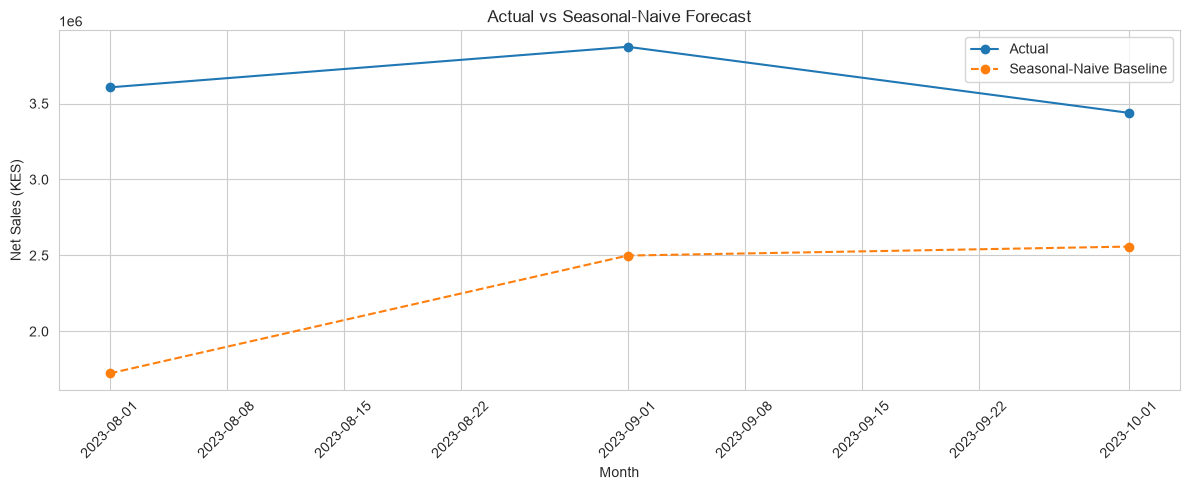

In [40]:
# Plot actual sales against the seasonal-naive baseline.

plt.figure(figsize=(12, 5))

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    seasonal_naive_forecast.index,
    seasonal_naive_forecast.values,
    marker="o",
    linestyle="--",
    label="Seasonal-Naive Baseline"
)

plt.title("Actual vs Seasonal-Naive Forecast")
plt.xlabel("Month")
plt.ylabel("Net Sales (KES)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 
Plots the actual sales for the three-month test period against the seasonal-naive predictions to visually assess the baseline's forecasting accuracy.

### 4.6 Holt-Winters Exponential Smoothing Model

The first advanced forecasting model will be Holt-Winters Exponential Smoothing.

This model is suitable because the EDA identified a growing sales pattern and the dataset contains monthly observations where annual seasonality may exist.

The model will account for:

- Level — the current sales level.
- Trend — the direction of sales growth or decline.
- Seasonality — recurring monthly patterns.

The model will be trained only on the training period and evaluated on the same three-month test period used for the baseline.

In [41]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Train a Holt-Winters model using only the training data.
# Additive trend and additive yearly seasonality are used because
# the dataset contains monthly sales and only three yearly cycles.

holt_winters_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated"
).fit()

# Forecast the three months in the test period.
holt_winters_forecast = holt_winters_model.forecast(TEST_MONTHS)

# Keep the same index as the test data.
holt_winters_forecast.index = test.index

# Evaluate the model.
holt_winters_wape = wape_percent(
    test,
    holt_winters_forecast
)

print(f"Holt-Winters WAPE: {holt_winters_wape:.2f}%")

Holt-Winters WAPE: 15.18%


 
Fits a Holt-Winters model using only the training data, forecasts the three unseen test months and calculates WAPE for comparison with the seasonal-naive baseline.

### 4.7 SARIMA Forecasting Model

SARIMA will be evaluated as a second candidate forecasting model.

SARIMA can model both non-seasonal and seasonal patterns in a time series. The seasonal period is set to 12 because the data is monthly and annual seasonality is therefore represented by a 12-month cycle.

The model is trained only on the training period and evaluated against the same three-month test set.

Because the dataset contains only 36 months, model complexity will be kept limited to reduce the risk of overfitting.

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit a relatively simple SARIMA model.
# The seasonal period of 12 represents yearly seasonality in monthly data.

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast the three unseen test months.
sarima_forecast = sarima_model.forecast(steps=TEST_MONTHS)

# Match the forecast index to the test period.
sarima_forecast.index = test.index

# Evaluate SARIMA using WAPE.
sarima_wape = wape_percent(
    test,
    sarima_forecast
)

print(f"SARIMA WAPE: {sarima_wape:.2f}%")

SARIMA WAPE: 10.21%


  
Fits a seasonal ARIMA model to the training period, generates a three-month forecast and calculates its WAPE on the held-out test period.

### 4.8 Additional Candidate Models and a Common Interface

Holt-Winters and SARIMA were fitted above with one specification each. Because the series is short and grows strongly, a few well-motivated alternatives are added so that the selection does not rest on a single specification:

- **Holt-Winters with a damped trend**: stops the trend growing without limit.
- **Holt (trend only, no seasonality)**: tests whether seasonality adds anything, given at most three cycles.
- **SARIMA(0,1,1)(0,1,1,12)**: a classic, parsimonious seasonal specification with fewer parameters than the first SARIMA.
- **Seasonal-naive with year-on-year growth**: last year's value for the same month, scaled by the growth of the latest 3 months over the same 3 months a year earlier. It uses only past data and is a transparent answer to strong growth.

All models are placed behind two functions, `fit_spec` and `forecast_spec`, so that the same code serves validation, testing, the final forecast and deployment. The Holt-Winters additive and first SARIMA specifications are identical to those fitted above.

In [43]:
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

BASELINE = "Seasonal-Naive"
MODEL_SPECS = {
    "Seasonal-Naive":              {"kind": "snaive"},
    "Seasonal-Naive + YoY growth": {"kind": "snaive_growth", "window": 3},
    "Holt-Winters (additive)":     {"kind": "hw", "trend": "add", "damped": False, "seasonal": "add"},
    "Holt-Winters (damped trend)": {"kind": "hw", "trend": "add", "damped": True,  "seasonal": "add"},
    "Holt (trend, no seasonality)": {"kind": "hw", "trend": "add", "damped": False, "seasonal": None},
    "SARIMA(1,1,1)(1,1,0,12)":     {"kind": "sarima", "order": (1, 1, 1), "seasonal_order": (1, 1, 0, 12)},
    "SARIMA(0,1,1)(0,1,1,12)":     {"kind": "sarima", "order": (0, 1, 1), "seasonal_order": (0, 1, 1, 12)},
}

def _future_index(y, h):
    """The h month-start dates that follow the last observation."""
    return pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=h, freq="MS")

def fit_spec(name, y):
    """Fit a model on series y. Returns the fitted results, or None for the naive methods."""
    spec, y = MODEL_SPECS[name], y.asfreq("MS")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        if spec["kind"] == "hw":
            return ExponentialSmoothing(
                y, trend=spec["trend"], damped_trend=spec["damped"], seasonal=spec["seasonal"],
                seasonal_periods=12 if spec["seasonal"] else None,
                initialization_method="estimated").fit()
        if spec["kind"] == "sarima":
            return SARIMAX(y, order=spec["order"], seasonal_order=spec["seasonal_order"],
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return None

def forecast_spec(name, y, h):
    """Forecast the next h months (h <= 12) using only the observations in y."""
    spec, y = MODEL_SPECS[name], y.asfreq("MS")
    idx = _future_index(y, h)
    if spec["kind"] in ("snaive", "snaive_growth"):
        values = y.reindex(idx - pd.DateOffset(years=1)).to_numpy(dtype=float)   # same month last year
        if spec["kind"] == "snaive_growth":
            recent = y.iloc[-spec["window"]:]
            prior = y.reindex(recent.index - pd.DateOffset(years=1)).to_numpy(dtype=float)
            values = values * (recent.to_numpy(dtype=float).sum() / prior.sum())   # NaN if history is too short
        return pd.Series(values, index=idx)
    return pd.Series(np.asarray(fit_spec(name, y).forecast(h), dtype=float), index=idx)

def safe_forecast(name, y, h):
    """Like forecast_spec, but returns NaN instead of failing, so one bad fit cannot stop a comparison."""
    try:
        fc = forecast_spec(name, y, h)
        if not np.isfinite(fc.to_numpy()).all():
            fc[:] = np.nan
    except Exception:
        fc = pd.Series(np.nan, index=_future_index(y.asfreq("MS"), h))
    return fc

print(f"{len(MODEL_SPECS)} models registered ({len(MODEL_SPECS) - 1} candidates plus the baseline):")
print("\n".join(f"- {name}" for name in MODEL_SPECS))

7 models registered (6 candidates plus the baseline):
- Seasonal-Naive
- Seasonal-Naive + YoY growth
- Holt-Winters (additive)
- Holt-Winters (damped trend)
- Holt (trend, no seasonality)
- SARIMA(1,1,1)(1,1,0,12)
- SARIMA(0,1,1)(0,1,1,12)


Registers the baseline and six candidates behind one interface. A failed or non-finite fit returns missing values, which later steps treat as an unavailable result rather than a silent zero.

### 4.9 Rolling-Origin Validation on the Training Period

To choose between candidates **without touching the test months**, each model is repeatedly fitted on the first *k* training months and asked to forecast the next 3, with *k* running from 24 to 30. Twenty-four months is the minimum that gives two full seasonal cycles. The 7 resulting folds cover 21 forecasts, all inside the 33-month training window. The pooled validation WAPE of each model is its score.

The folds cover only the later, faster-growing part of the series, so the validation scores describe recent behaviour. They are still more reliable than a single 3-month test, because they average over several origins.

In [44]:
CV_MIN_TRAIN = 24            # two full yearly cycles
CV_HORIZON = TEST_MONTHS     # same 3-month horizon as the test and the final forecast

def rolling_origin_cv(y_train, name):
    """Forecast the next CV_HORIZON months from each origin; uses only data before each forecast."""
    rows = []
    for end in range(CV_MIN_TRAIN, len(y_train) - CV_HORIZON + 1):
        history, actual = y_train.iloc[:end], y_train.iloc[end:end + CV_HORIZON]
        fc = safe_forecast(name, history, CV_HORIZON)
        rows.append(pd.DataFrame({"model": name, "origin": history.index[-1], "month": actual.index,
                                  "horizon": np.arange(1, CV_HORIZON + 1),
                                  "actual": actual.to_numpy(), "forecast": fc.to_numpy()}))
    return pd.concat(rows, ignore_index=True)

# Validation uses ONLY the training series; the test months are never touched here.
cv_frames = {name: rolling_origin_cv(train, name) for name in MODEL_SPECS}

cv_rows = []
for name, g in cv_frames.items():
    failed = g.loc[g["forecast"].isna(), "origin"].nunique()
    ok = failed == 0
    cv_rows.append({"Model": name, "Folds": g["origin"].nunique(), "Failed folds": failed,
                    "CV WAPE (%)": wape_percent(g["actual"], g["forecast"]) if ok else np.nan,
                    "CV MAE": mae(g["actual"], g["forecast"]) if ok else np.nan})
cv_table = pd.DataFrame(cv_rows)
cv_base = cv_table.loc[cv_table["Model"] == BASELINE, "CV WAPE (%)"].iloc[0]
cv_table["CV improvement vs baseline (%)"] = improvement_vs_baseline(cv_table["CV WAPE (%)"], cv_base)
cv_table = cv_table.sort_values("CV WAPE (%)").reset_index(drop=True)

print(f"Training months: {len(train)} | validation folds per model: {cv_table['Folds'].iloc[0]} "
      f"(origins {train.index[CV_MIN_TRAIN - 1]:%Y-%m} to {train.index[-CV_HORIZON - 1]:%Y-%m})")
display(cv_table.round(2))

Training months: 33 | validation folds per model: 7 (origins 2022-10 to 2023-04)


,Model,Folds,Failed folds,CV WAPE (%),CV MAE,CV improvement vs baseline (%)
0,"SARIMA(0,1,1)(0,1,1,12)",7,0,13.52,528839.47,76.91
1,Holt-Winters (damped trend),7,0,14.85,580700.49,74.65
2,Holt-Winters (additive),7,0,15.29,598041.85,73.89
3,"Holt (trend, no seasonality)",7,0,15.99,625419.68,72.69
4,Seasonal-Naive + YoY growth,7,0,18.62,728052.27,68.21
5,Seasonal-Naive,7,0,58.57,2290424.32,0.00
6,"SARIMA(1,1,1)(1,1,0,12)",7,0,89.99,3519106.93,-53.64


Runs the rolling-origin validation for every model and ranks them by pooled validation WAPE. A model with failed folds is given no score and cannot be selected. Because the training windows grow from 24 to 30 months, each fold only uses information that was available at that origin.

### 4.10 Model Selection

**Selection rule (fixed before the test results are viewed):** among the candidates, choose the one with the lowest validation WAPE on the training period. The seasonal-naive baseline is the benchmark and is not eligible. The test months play no part in this choice.

In [45]:
eligible = cv_table[(cv_table["Model"] != BASELINE) & cv_table["CV WAPE (%)"].notna()]
assert len(eligible) > 0, "No candidate produced a complete set of validation forecasts"

selected_model = eligible.sort_values("CV WAPE (%)").iloc[0]["Model"]
selected_cv_wape = eligible.sort_values("CV WAPE (%)").iloc[0]["CV WAPE (%)"]

print(f"Selected model (lowest validation WAPE): {selected_model}")
print(f"Validation WAPE: {selected_cv_wape:.2f}% | baseline validation WAPE: {cv_base:.2f}%")
if selected_cv_wape >= cv_base:
    print("Note: no candidate beat the seasonal-naive baseline in validation.")

Selected model (lowest validation WAPE): SARIMA(0,1,1)(0,1,1,12)
Validation WAPE: 13.52% | baseline validation WAPE: 58.57%


 Applies the selection rule and stores the chosen model in `selected_model`. The choice rests on training-period validation only.

### 4.11 Test-Set Comparison of All Models

Every model is now fitted once on the 33 training months and scored on the same 3 held-out months. This is the unbiased accuracy check, reported for all models so the comparison is complete. The selected model is **not** switched to whichever model happens to score best on the test months, since that would tune against the test set.

In [46]:
# Fit every model on the training months only and forecast the held-out test months.
test_forecasts = {name: safe_forecast(name, train, TEST_MONTHS) for name in MODEL_SPECS}
assert all(fc.index.equals(test.index) for fc in test_forecasts.values()), "Forecast months differ from the test months"

# Consistency with the stand-alone fits in 4.4, 4.6 and 4.7 (same models, same data).
assert np.allclose(test_forecasts["Seasonal-Naive"], seasonal_naive_forecast, equal_nan=True)
assert np.allclose(test_forecasts["Holt-Winters (additive)"], holt_winters_forecast, rtol=1e-4)
assert np.allclose(test_forecasts["SARIMA(1,1,1)(1,1,0,12)"], sarima_forecast, rtol=1e-4)

rows = []
for name, fc in test_forecasts.items():
    ok = fc.notna().all()
    rows.append({"Model": name,
                 "CV WAPE (%)": cv_table.loc[cv_table["Model"] == name, "CV WAPE (%)"].iloc[0],
                 "Test WAPE (%)": wape_percent(test, fc) if ok else np.nan,
                 "Test MAE (KES)": mae(test, fc) if ok else np.nan,
                 "Test RMSE (KES)": rmse(test, fc) if ok else np.nan})
model_results = pd.DataFrame(rows)
baseline_test_wape = model_results.loc[model_results["Model"] == BASELINE, "Test WAPE (%)"].iloc[0]
model_results["Improvement vs Baseline (%)"] = improvement_vs_baseline(model_results["Test WAPE (%)"], baseline_test_wape)
model_results["Selected"] = model_results["Model"].eq(selected_model)
model_results = model_results.sort_values("Test WAPE (%)").reset_index(drop=True)

display(model_results.round(2))

lowest_test_model = model_results.dropna(subset=["Test WAPE (%)"]).iloc[0]["Model"]
print(f"Selected by validation: {selected_model}")
print(f"Lowest test WAPE      : {lowest_test_model}")
if lowest_test_model != selected_model:
    print("The two differ. The validation-based choice is kept, because choosing on the test months would tune against them.")

,Model,CV WAPE (%),Test WAPE (%),Test MAE (KES),Test RMSE (KES),Improvement vs Baseline (%),Selected
0,"SARIMA(0,1,1)(0,1,1,12)",13.52,5.57,202822.96,227776.12,85.30,True
1,"Holt (trend, no seasonality)",15.99,7.71,280654.64,352333.90,79.65,False
2,"SARIMA(1,1,1)(1,1,0,12)",89.99,10.21,371732.76,444650.28,73.05,False
3,Holt-Winters (damped trend),14.85,10.62,386559.49,421445.61,71.98,False
4,Holt-Winters (additive),15.29,15.18,552315.58,589107.72,59.96,False
5,Seasonal-Naive,58.57,37.90,1379369.00,1438862.65,0.00,False
6,Seasonal-Naive + YoY growth,18.62,38.63,1406140.79,1646245.88,-1.94,False


Selected by validation: SARIMA(0,1,1)(0,1,1,12)
Lowest test WAPE      : SARIMA(0,1,1)(0,1,1,12)


Scores all models on the three test months and builds `model_results`. The assertions confirm that the registry reproduces the stand-alone fits from 4.4, 4.6 and 4.7. If the selected model is not the one with the lowest test WAPE, the notebook says so and keeps the validation-based choice. The Evaluation phase decides whether the targets are met.

### 4.12 Forecasting Total Monthly Sales for the Next Three Months

The selected model is refitted on **all 36 months**, since the test months are now known history, and used to forecast the three months after the last observation.

**Uncertainty.** Model-based intervals from a few dozen points would be too narrow. Instead, a range is derived from the selected model's own out-of-sample errors in the rolling-origin validation: the 80th percentile of its absolute percentage errors, applied above and below each forecast. It is an approximate, symmetric 80% range, based on 21 validation forecasts from the later part of the series. It is not a statistical guarantee.

In [47]:
FORECAST_HORIZON = 3
INTERVAL_LEVEL = 0.80

full_series = forecast_df["net_sales"].asfreq("MS")
final_forecast = safe_forecast(selected_model, full_series, FORECAST_HORIZON)
assert final_forecast.notna().all(), "The selected model failed on the full series"

# Empirical range from the selected model's validation errors (training-period data only).
cv_sel = cv_frames[selected_model]
abs_pct_err = (cv_sel["actual"] - cv_sel["forecast"]).abs() / cv_sel["actual"]
interval_pct = float(abs_pct_err.quantile(INTERVAL_LEVEL))

forecast_table = pd.DataFrame({
    "forecast": final_forecast,
    "lower": final_forecast * (1 - interval_pct),
    "upper": final_forecast * (1 + interval_pct),
}).rename_axis("month")

print(f"Model: {selected_model} | fitted on {full_series.index.min():%Y-%m} to {full_series.index.max():%Y-%m}")
print(f"Approximate {INTERVAL_LEVEL:.0%} range: forecast +/- {interval_pct:.1%} (from validation errors)")
display(forecast_table.round(0))

Model: SARIMA(0,1,1)(0,1,1,12) | fitted on 2020-11 to 2023-10
Approximate 80% range: forecast +/- 26.0% (from validation errors)


,forecast,lower,upper
month,,,
2023-11-01,3937376.0,2914220.0,4960531.0
2023-12-01,3967567.0,2936566.0,4998567.0
2024-01-01,4093703.0,3029925.0,5157481.0


Refits the selected model on the full series, forecasts the next three months and attaches an approximate 80% range from validation errors. The forecast starts the month after the last month in the data.

### 4.13 Forecast Visualization

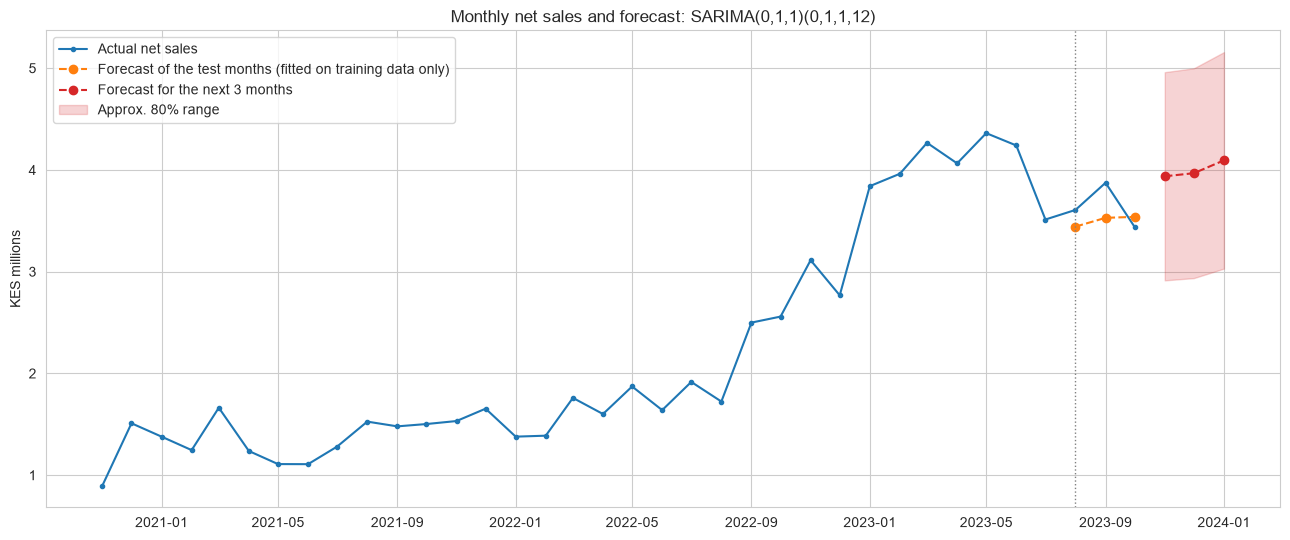

In [48]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(full_series.index, full_series / 1e6, marker="o", ms=3, label="Actual net sales")
ax.plot(test_forecasts[selected_model].index, test_forecasts[selected_model] / 1e6, ls="--", marker="o",
        label="Forecast of the test months (fitted on training data only)")
ax.plot(forecast_table.index, forecast_table["forecast"] / 1e6, ls="--", marker="o", color="tab:red",
        label="Forecast for the next 3 months")
ax.fill_between(forecast_table.index, forecast_table["lower"] / 1e6, forecast_table["upper"] / 1e6,
                alpha=0.2, color="tab:red", label=f"Approx. {INTERVAL_LEVEL:.0%} range")
ax.axvline(test.index[0], color="grey", ls=":", lw=1)
ax.set(title=f"Monthly net sales and forecast: {selected_model}", ylabel="KES millions", xlabel="")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

Plots the full history, the selected model's forecast of the test months (to compare with what happened), and the three-month forecast with its range. The dotted vertical line marks the start of the test period.

### 4.14 Category-Level Forecasting

After evaluating the total monthly sales models, forecasting will be extended to the core product categories identified during Data Preparation.

Only categories marked as `core_category` will be modeled because the dataset contains only 36 monthly observations and sparse categories may not provide enough information for reliable forecasting.

The same chronological train/test split and WAPE metric are applied to each core category, comparing the seasonal-naive baseline with the model selected for total sales. The model is **not** re-tuned per category, because 36 points per category would invite overfitting.

This allows the retailer to identify which major categories are likely to drive future demand and stock requirements.

In [49]:
# Identify the core categories selected during Data Preparation.
core_categories = (
    forecast_cat_df.loc[
        forecast_cat_df["core_category"],
        "category"
    ]
    .dropna()
    .unique()
)

print(f"Core categories selected for forecasting: {len(core_categories)}")
print("\n".join(f"- {category}" for category in core_categories))

Core categories selected for forecasting: 4
- Baby Diapers
- Baby Formula
- Bathing & Skin Care
- Feeding and weaning


 
Retrieves the categories already identified as sufficiently important and continuous during Data Preparation. These categories become the candidates for category-level forecasting.

In [50]:
# Order core categories by sales share (profile comes from Data Preparation 3.14).
core_categories = [c for c in profile.index if c in set(core_categories)]

cat_rows, cat_test_fc, cat_future = [], {}, {}
for category in core_categories:
    s = forecast_cat_wide[category].astype(float).asfreq("MS")
    c_train, c_test = s.iloc[:-TEST_MONTHS], s.iloc[-TEST_MONTHS:]

    base_fc = safe_forecast(BASELINE, c_train, TEST_MONTHS)
    model_fc = safe_forecast(selected_model, c_train, TEST_MONTHS)
    cat_test_fc[category] = model_fc

    base_w, model_w = wape_percent(c_test, base_fc), wape_percent(c_test, model_fc)
    cat_rows.append({"Category": category,
                     "Share of product sales (%)": profile.loc[category, "share"] * 100,
                     "Baseline WAPE (%)": base_w,
                     "Model WAPE (%)": model_w,
                     "Improvement vs Baseline (%)": improvement_vs_baseline(model_w, base_w),
                     "Test MAE (KES)": mae(c_test, model_fc) if model_fc.notna().all() else np.nan})

    # Refit on all 36 months and forecast the next 3 months.
    cat_future[category] = safe_forecast(selected_model, s, FORECAST_HORIZON)

category_results = pd.DataFrame(cat_rows)
category_forecast = pd.DataFrame(cat_future).rename_axis("month")
category_forecast.columns.name = None

print(f"Category model: {selected_model} (same specification as total sales, refitted per category)")
display(category_results.round(2))
display(category_forecast.round(0))

Category model: SARIMA(0,1,1)(0,1,1,12) (same specification as total sales, refitted per category)


,Category,Share of product sales (%),Baseline WAPE (%),Model WAPE (%),Improvement vs Baseline (%),Test MAE (KES)
0,Baby Formula,57.43,58.87,9.65,83.60,256538.39
1,Bathing & Skin Care,9.57,77.27,88.94,-15.11,133772.80
2,Feeding and weaning,9.55,16.14,25.55,-58.35,70306.01
3,Baby Diapers,7.06,22.41,15.41,31.23,16736.49


,Baby Formula,Bathing & Skin Care,Feeding and weaning,Baby Diapers
month,,,,
2023-11-01,2864208.0,242512.0,362247.0,262677.0
2023-12-01,2791872.0,80657.0,366090.0,270328.0
2024-01-01,2971609.0,165405.0,364434.0,267775.0


For each core category, fits the baseline and the selected model on the first 33 months, scores both on the 3 test months, then refits on all 36 months to forecast the next three months. The results are stored in `category_results` and `category_forecast`. Category forecasts are not expected to add up to the total forecast, because the four core categories cover only part of product sales and each model is fitted separately.

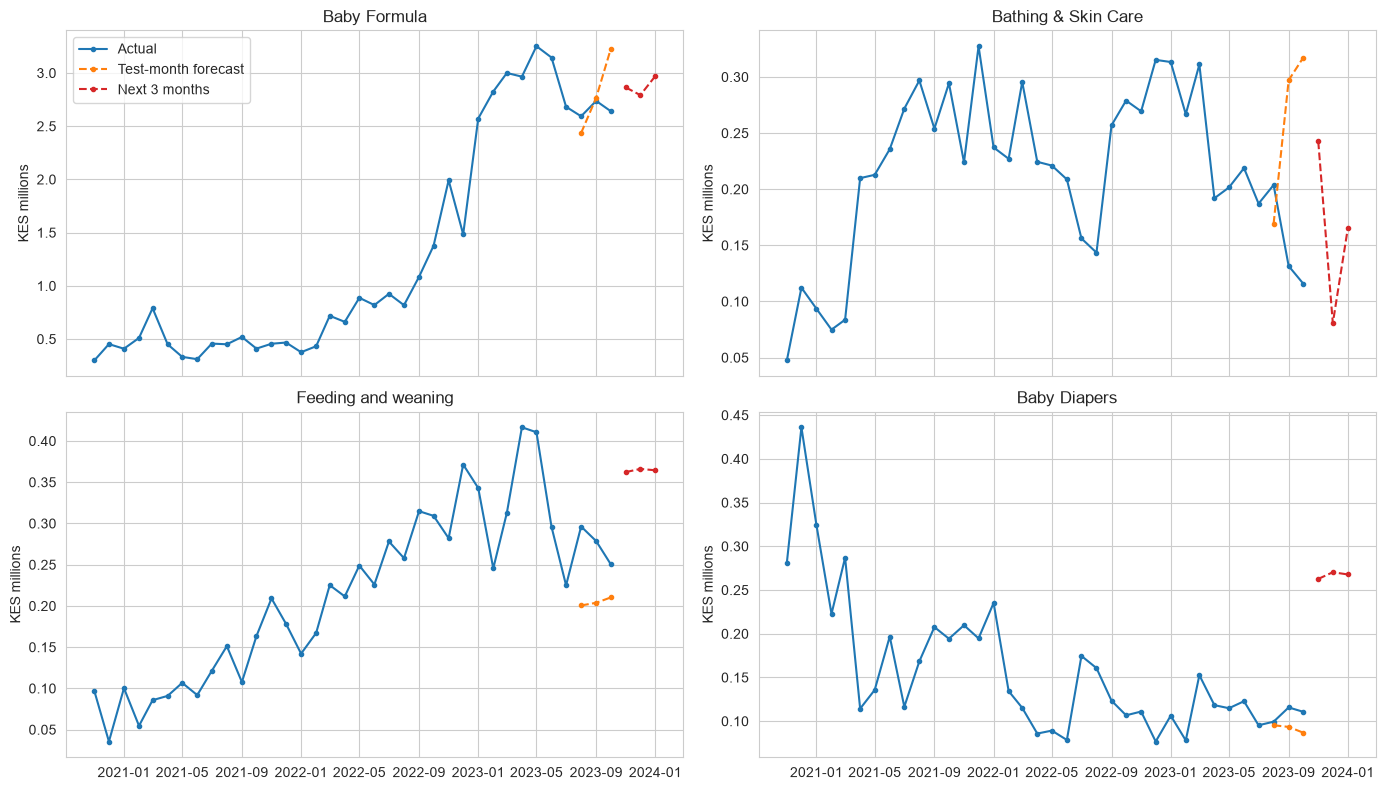

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, category in zip(axes.ravel(), core_categories):
    s = forecast_cat_wide[category]
    ax.plot(s.index, s / 1e6, marker="o", ms=3, label="Actual")
    ax.plot(cat_test_fc[category].index, cat_test_fc[category] / 1e6, ls="--", marker="o", ms=3, label="Test-month forecast")
    ax.plot(category_forecast.index, category_forecast[category] / 1e6, ls="--", marker="o", ms=3, color="tab:red", label="Next 3 months")
    ax.set_title(category); ax.set_ylabel("KES millions")
axes.ravel()[0].legend()
plt.tight_layout(); plt.show()

plots actual sales, the test-month forecast and the three-month forecast for each core category, so that their direction and size can be judged by eye.

### 4.15 Modeling Summary

**Produced in this phase**
- A chronological split: 33 training months and 3 test months (August to October 2023).
- A seasonal-naive baseline and six candidate models: a growth-adjusted seasonal-naive forecast, three exponential smoothing variants and two SARIMA specifications.
- Rolling-origin validation on the training period, used to select the model without touching the test months.
- A test-set comparison of all models on WAPE, MAE and RMSE, with improvement over the baseline.
- A forecast of total net sales for the three months after the data ends, with an approximate 80% range.
- Category-level forecasts for the four core categories.

**Passed to Evaluation:** `selected_model`, `model_results`, `cv_table`, `test_forecasts`, `forecast_table`, `category_results` and `category_forecast`.

Whether the selected model meets the success criteria is decided in Phase 5, not here.

## 5. Evaluation

The Evaluation phase judges the forecasting solution from Phase 4 against the business and data science objectives and the success criteria fixed in Section 1.6. It covers:

- performance against the seasonal-naive baseline, using WAPE, MAE and RMSE on the 3-month test period;
- improvement over the baseline;
- actual versus predicted sales and forecast error patterns;
- forecast reliability and limitations;
- category-level performance;
- alignment with the business objectives, and whether the forecasting component is ready for further validation or deployment.

Every pass or fail in this phase is calculated from the results of the code. If a result is unavailable, it is reported as **PENDING** rather than as a pass or a fail.

### 5.1 Forecasting Performance

All models were scored on the same 3 test months (August to October 2023). The test months were not used to fit or to select the model. The table also shows each model's validation WAPE from the training period, which is what the selection was based on.

In [52]:
display(model_results.round(2))

selected_row = model_results.loc[model_results["Model"] == selected_model].iloc[0]
best_model = selected_model
best_wape = selected_row["Test WAPE (%)"]
best_improvement = selected_row["Improvement vs Baseline (%)"]

print(f"Selected model          : {best_model}")
print(f"Test WAPE               : {best_wape:.2f}%")
print(f"Test MAE / RMSE (KES)   : {selected_row['Test MAE (KES)']:,.0f} / {selected_row['Test RMSE (KES)']:,.0f}")
print(f"Baseline test WAPE      : {baseline_test_wape:.2f}%")
print(f"Improvement vs baseline : {best_improvement:.2f}%")

,Model,CV WAPE (%),Test WAPE (%),Test MAE (KES),Test RMSE (KES),Improvement vs Baseline (%),Selected
0,"SARIMA(0,1,1)(0,1,1,12)",13.52,5.57,202822.96,227776.12,85.30,True
1,"Holt (trend, no seasonality)",15.99,7.71,280654.64,352333.90,79.65,False
2,"SARIMA(1,1,1)(1,1,0,12)",89.99,10.21,371732.76,444650.28,73.05,False
3,Holt-Winters (damped trend),14.85,10.62,386559.49,421445.61,71.98,False
4,Holt-Winters (additive),15.29,15.18,552315.58,589107.72,59.96,False
5,Seasonal-Naive,58.57,37.90,1379369.00,1438862.65,0.00,False
6,Seasonal-Naive + YoY growth,18.62,38.63,1406140.79,1646245.88,-1.94,False


Selected model          : SARIMA(0,1,1)(0,1,1,12)
Test WAPE               : 5.57%
Test MAE / RMSE (KES)   : 202,823 / 227,776
Baseline test WAPE      : 37.90%
Improvement vs baseline : 85.30%


shows the model comparison and reads out the selected model's test WAPE, MAE, RMSE and improvement over the seasonal-naive baseline. For reference, the outputs saved in 4.4, 4.6 and 4.7 show the first three fits on the same test months: the seasonal-naive baseline scored 37.90% WAPE, Holt-Winters 15.18% and SARIMA 10.21%. The expanded comparison above is the one that decides the outcome.

### 5.2 Forecasting Success Criteria

The selected model is evaluated against the criteria in Section 1.6, with the thresholds unchanged:

- WAPE of 15% or lower on the 3 test months.
- Improvement over the seasonal-naive baseline of at least 10%.

Both must be met for the forecasting objective to be considered achieved. A criterion whose result is unavailable is reported as PENDING, and a model that misses a target is reported as not meeting it, even if it is the best of the models tested.

In [53]:
WAPE_TARGET = 15.0
BASELINE_IMPROVEMENT_TARGET = 10.0

def criterion_status(actual, passed):
    """PASS / FAIL, or PENDING when the result is unavailable."""
    return "PENDING" if actual is None or pd.isna(actual) else ("PASS" if passed else "FAIL")

wape_status = criterion_status(best_wape, best_wape <= WAPE_TARGET)
improvement_status = criterion_status(best_improvement, best_improvement >= BASELINE_IMPROVEMENT_TARGET)

forecast_evaluation = pd.DataFrame({
    "Criterion": ["WAPE <= 15%", "Improvement over seasonal-naive >= 10%"],
    "Actual": [f"{best_wape:.2f}%", f"{best_improvement:.2f}%"],
    "Target": [f"<= {WAPE_TARGET:.1f}%", f">= {BASELINE_IMPROVEMENT_TARGET:.1f}%"],
    "Result": [wape_status, improvement_status],
})
display(forecast_evaluation)

,Criterion,Actual,Target,Result
0,WAPE <= 15%,5.57%,<= 15.0%,PASS
1,Improvement over seasonal-naive >= 10%,85.30%,>= 10.0%,PASS


**What the code does:** tests the selected model against the two predefined targets and records PASS, FAIL or PENDING for each. The thresholds are the ones from Business Understanding and have not been changed.

### 5.3 Actual versus Forecast

Metrics alone do not show the whole picture. The test-month forecasts of every model are compared with the actual sales to see whether each model follows the direction and size of sales, and whether it consistently under- or over-predicts.

,Actual,Seasonal-Naive,Seasonal-Naive + YoY growth,Holt-Winters (additive),Holt-Winters (damped trend),"Holt (trend, no seasonality)","SARIMA(1,1,1)(1,1,0,12)","SARIMA(0,1,1)(0,1,1,12)"
month,,,,,,,,
2023-08-01,3606663.0,1723355.0,3847187.0,4040162.0,3901269.0,3840030.0,4274380.0,3442548.0
2023-09-01,3873635.0,2499184.0,5579134.0,4256438.0,4116591.0,3920288.0,3803478.0,3529010.0
2023-10-01,3438602.0,2558254.0,5711001.0,4279247.0,4060719.0,4000546.0,3815927.0,3538331.0


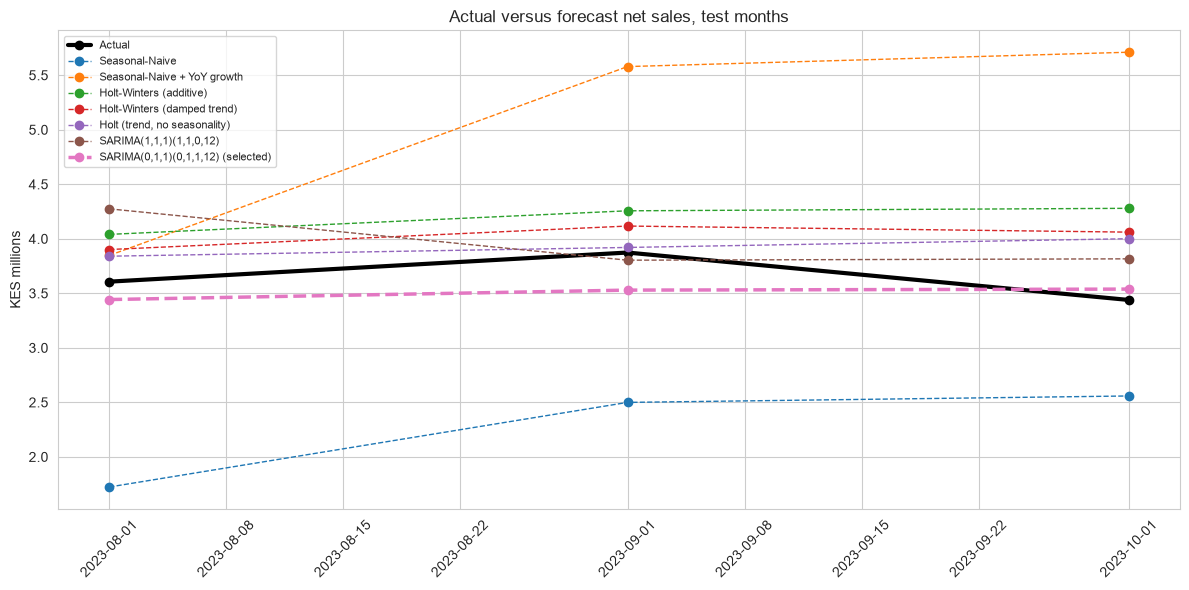

In [54]:
comparison_df = pd.DataFrame({"Actual": test}).join(pd.DataFrame(test_forecasts))
display(comparison_df.round(0))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(test.index, test / 1e6, marker="o", lw=3, color="black", label="Actual")
for name, fc in test_forecasts.items():
    if fc.notna().all():                       # models that failed are not drawn
        ax.plot(fc.index, fc / 1e6, marker="o", ls="--", lw=2.5 if name == selected_model else 1,
                label=f"{name} (selected)" if name == selected_model else name)
ax.set(title="Actual versus forecast net sales, test months", ylabel="KES millions", xlabel="")
ax.legend(fontsize=8, loc="best")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

tabulates and plots the actual test-month sales against the forecast of every model that produced a valid forecast. The selected model is drawn with a thicker line.

### 5.4 Forecast Error Analysis

Errors are examined to see whether the selected model has a systematic tendency to under- or over-forecast. The error is **Actual − Forecast**, so a positive error means sales were under-forecast. Errors are shown for the three test months and, with more points, for the rolling-origin validation by forecast horizon.

In [55]:
best_forecast = test_forecasts[selected_model]
error_df = pd.DataFrame({"Actual": test, "Forecast": best_forecast})
error_df["Error"] = error_df["Actual"] - error_df["Forecast"]
error_df["Absolute % Error"] = error_df["Error"].abs() / error_df["Actual"] * 100
display(error_df.round(1))

bias = error_df["Error"].mean()
print(f"Mean error (bias)   : {bias:,.0f} KES -> "
      f"{'under-forecast' if bias > 0 else 'over-forecast'} on average")
print(f"Mean absolute error : {error_df['Error'].abs().mean():,.0f} KES")
print(f"Months with the same error sign: {(np.sign(error_df['Error']) == np.sign(bias)).sum()} of {len(error_df)}")

# Validation errors of the selected model, by forecast horizon (1 = next month).
cv_sel = cv_frames[selected_model].assign(error=lambda d: d["actual"] - d["forecast"])
by_horizon = (cv_sel.groupby("horizon")
              .apply(lambda g: pd.Series({"WAPE (%)": wape_percent(g["actual"], g["forecast"]),
                                          "Mean error (KES)": g["error"].mean()}), include_groups=False))
display(by_horizon.round(1))

,Actual,Forecast,Error,Absolute % Error
2023-08-01,3606663.0,3442548.3,164114.7,4.6
2023-09-01,3873635.0,3529010.1,344624.9,8.9
2023-10-01,3438602.0,3538331.3,-99729.3,2.9


Mean error (bias)   : 136,337 KES -> under-forecast on average
Mean absolute error : 202,823 KES
Months with the same error sign: 2 of 3


,WAPE (%),Mean error (KES)
horizon,,
1,11.3,228407.6
2,11.7,336254.0
3,17.4,427228.9


reports the error of the selected model for each test month, its average direction (bias) and size, and its validation error by forecast horizon. A large bias in one direction, or errors that grow with the horizon, would mean the forecasts need a manual adjustment or a shorter horizon. Read the printed values before relying on the forecast.

### 5.5 Category-Level Forecast Evaluation

Category-level performance matters because total sales can look accurate while individual categories are not. Each core category is scored on the same 3 test months against its own seasonal-naive baseline. No accuracy target was defined for categories in Section 1.6, so the results are **descriptive** and are not scored as pass or fail.

In [56]:
if "category_results" in globals() and len(category_results):
    display(category_results.round(2))
    valid = category_results.dropna(subset=["Model WAPE (%)"])
    n_better = int((valid["Improvement vs Baseline (%)"] > 0).sum())
    print(f"Categories forecast: {len(category_results)} | model beat its baseline in {n_better} of {len(valid)}")
    print(f"Model WAPE range: {valid['Model WAPE (%)'].min():.1f}% to {valid['Model WAPE (%)'].max():.1f}%")
    weakest = valid.sort_values("Model WAPE (%)").iloc[-1]
    print(f"Weakest category: {weakest['Category']} ({weakest['Model WAPE (%)']:.1f}% WAPE)")
else:
    print("PENDING: category results are not available. Run the category forecasting in Section 4.14 first.")

,Category,Share of product sales (%),Baseline WAPE (%),Model WAPE (%),Improvement vs Baseline (%),Test MAE (KES)
0,Baby Formula,57.43,58.87,9.65,83.60,256538.39
1,Bathing & Skin Care,9.57,77.27,88.94,-15.11,133772.80
2,Feeding and weaning,9.55,16.14,25.55,-58.35,70306.01
3,Baby Diapers,7.06,22.41,15.41,31.23,16736.49


Categories forecast: 4 | model beat its baseline in 2 of 4
Model WAPE range: 9.7% to 88.9%
Weakest category: Bathing & Skin Care (88.9% WAPE)


summarises category-level accuracy against each category's baseline and names the weakest category. Categories where the model does not beat its baseline, or where WAPE is high, should be forecast with more caution or reviewed with the business.

### 5.6 Forecast Reliability and Limitations

How far can the forecast be trusted? The checks below compare validation and test accuracy, show how much the validation accuracy varied between origins, and report the width of the forecast range.

In [57]:
fold_wape = (cv_frames[selected_model].groupby("origin")
             .apply(lambda g: wape_percent(g["actual"], g["forecast"]), include_groups=False))

reliability = pd.DataFrame({
    "Measure": ["Validation WAPE (training period, 21 forecasts)",
                "Test WAPE (3 held-out months)",
                "Validation WAPE by origin: lowest",
                "Validation WAPE by origin: highest",
                "Half-width of the ~80% forecast range"],
    "Value": [f"{selected_cv_wape:.1f}%", f"{best_wape:.1f}%", f"{fold_wape.min():.1f}%",
              f"{fold_wape.max():.1f}%", f"{interval_pct:.1%}"],
})
display(reliability)

cv_ok = selected_cv_wape <= WAPE_TARGET
print(f"Validation WAPE within the {WAPE_TARGET:.0f}% target: {'yes' if cv_ok else 'no'}")
if wape_status == "PASS" and not cv_ok:
    print("Caution: the test result passes but the validation WAPE does not, so the pass may be due to the short test window.")
if wape_status == "FAIL" and cv_ok:
    print("Note: the validation WAPE is within target but the test WAPE is not. Investigate the test months.")

,Measure,Value
0,"Validation WAPE (training period, 21 forecasts)",13.5%
1,Test WAPE (3 held-out months),5.6%
2,Validation WAPE by origin: lowest,2.2%
3,Validation WAPE by origin: highest,33.5%
4,Half-width of the ~80% forecast range,26.0%


Validation WAPE within the 15% target: yes


Compares validation and test accuracy, shows how stable validation accuracy was across origins, and prints a caution if the two disagree. Limitations that apply whatever the numbers are:

- The test set has only 3 points, so its WAPE is a noisy estimate of future accuracy.
- Strong growth means accuracy depends on the growth rate continuing. A slowdown or a jump would raise errors.
- Only three yearly cycles exist, with a partial first month, so recurring seasonality is not established.
- Sales reflect availability: stock-outs would hide demand, and the data cannot show them.
- No promotions, prices, holidays or other external drivers are used, so one-off events are not anticipated.
- The forecast range is approximate and is based on a small number of validation forecasts.

### 5.7 Evaluation Against Business Objectives

The results are assessed against the three business objectives from Section 1.3. The status is generated from the results above. The third objective depends on the deliverables in Phase 6, so it is shown as pending until Deployment has run.

In [58]:
both_pass = (wape_status == "PASS") and (improvement_status == "PASS")
any_pending = "PENDING" in (wape_status, improvement_status)

obj1_status = "PENDING" if any_pending else ("Targets met on the test months" if both_pass else "Targets NOT met")
n_cat = len(category_results) if "category_results" in globals() else 0
obj2_status = (f"Delivered for {n_cat} core categories (descriptive, no target)" if n_cat else "PENDING")

business_objectives = pd.DataFrame({
    "Business objective": ["1. Forecast total monthly sales for the next 3 months",
                           "2. Show which major categories are expected to sell more or less",
                           "3. Make the forecasts easy to use"],
    "Evidence": [f"{best_model}: test WAPE {best_wape:.2f}%, {best_improvement:.2f}% better than baseline",
                 f"Category forecasts and test WAPE for {n_cat} core categories (Section 4.14)",
                 "Reusable function, forecast table and report (Phase 6)"],
    "Status": [obj1_status, obj2_status, "PENDING until Phase 6 has run"],
})
display(business_objectives)

,Business objective,Evidence,Status
0,1. Forecast total monthly sales for the next 3...,"SARIMA(0,1,1)(0,1,1,12): test WAPE 5.57%, 85.3...",Targets met on the test months
1,2. Show which major categories are expected to...,Category forecasts and test WAPE for 4 core ca...,"Delivered for 4 core categories (descriptive, ..."
2,3. Make the forecasts easy to use,"Reusable function, forecast table and report (...",PENDING until Phase 6 has run


connects the technical results back to the business objectives. The status of objective 1 follows the success-criteria result, and the status of objective 3 is confirmed in Deployment.

### 5.8 Overall Decision and Readiness

The decision below is generated from the results. A model that does not meet a predefined target is not described as successful just because it is the best of those tested, and a passing result on 3 test months is treated as a prototype-level result.

In [59]:
if any_pending:
    decision = ("PENDING: at least one success criterion could not be evaluated. "
                "Resolve the missing results before any decision.")
elif both_pass:
    decision = ("TARGETS MET on the 3-month test: WAPE and improvement over the baseline both meet the predefined "
                "thresholds. The forecasting component is ready for FURTHER VALIDATION (for example scoring it on "
                "new months as they arrive) and for use as an offline planning aid. It is not yet validated for "
                "unattended production use.")
else:
    failed = [name for name, status in [("WAPE", wape_status), ("improvement over baseline", improvement_status)]
              if status == "FAIL"]
    decision = (f"TARGETS NOT MET ({', '.join(failed)}). Do not deploy as a decision tool. Investigate: the unusual "
                "months in 3.13, the error pattern in 5.4, a longer history, and whether the growth rate changed "
                "during the test months.")

overall_evaluation = pd.DataFrame({
    "Evaluation area": ["Total sales: WAPE", "Total sales: improvement over baseline", "Category forecasts"],
    "Target": [f"<= {WAPE_TARGET:.1f}%", f">= {BASELINE_IMPROVEMENT_TARGET:.1f}%", "None defined (descriptive)"],
    "Actual": [f"{best_wape:.2f}%", f"{best_improvement:.2f}%", f"{n_cat} categories forecast"],
    "Result": [wape_status, improvement_status, "Reported"],
})
display(overall_evaluation)
print("\nDecision:", decision)

,Evaluation area,Target,Actual,Result
0,Total sales: WAPE,<= 15.0%,5.57%,PASS
1,Total sales: improvement over baseline,>= 10.0%,85.30%,PASS
2,Category forecasts,None defined (descriptive),4 categories forecast,Reported



Decision: TARGETS MET on the 3-month test: WAPE and improvement over the baseline both meet the predefined thresholds. The forecasting component is ready for FURTHER VALIDATION (for example scoring it on new months as they arrive) and for use as an offline planning aid. It is not yet validated for unattended production use.


summarises the success criteria and prints a decision that follows from them: pending, targets met (ready for further validation) or targets not met (with what to investigate).

### 5.9 Evaluation Summary

The Evaluation phase assessed only the forecasting solution. The seasonal-naive baseline, six candidate models and the selected model were compared on the same three test months, using WAPE as the primary metric with MAE and RMSE as support. The selected model was chosen on training-period validation, not on the test months.

The success criteria are WAPE of 15% or lower and at least 10% improvement over the baseline. Their status (PASS, FAIL or PENDING), the final decision, and the checks on error patterns, reliability and category results are produced by the code above and should be read from the outputs when the notebook is run. The main limitations are the short test window, the strong growth, the limited seasonal history and the lack of external drivers. These mean the forecasts are best used as a planning aid with a safety margin, and that accuracy must be monitored as new months arrive.

## 6. Deployment

This phase packages the forecasting solution so that the retailer can use it. What is built here is an **offline forecasting prototype**: saved configuration and model, a reusable function, a forecast report and written guidance. It is not a live production system, and no scheduled job, web service or dashboard has been deployed.

### 6.1 Save the Model, Configuration and Preprocessing Steps

The selected model is refitted on the full history and saved with a configuration file that records everything needed to reproduce the forecast: the target definition, the preprocessing steps, the model specification, the training period, the accuracy results and the package versions.

Two things are saved. The configuration and the history are the portable, version-independent route, since the model is rebuilt from them. The fitted model is also stored with `joblib` for convenience, but pickled models depend on the library versions recorded in the configuration.

In [60]:
import json, sys, datetime as dt
from pathlib import Path
import joblib
import statsmodels

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

def _num(x):
    """JSON-safe number (NaN becomes null)."""
    return None if x is None or pd.isna(x) else float(x)

final_fit = fit_spec(selected_model, full_series)           # None for the naive methods

config = {
    "project": "Sales Forecasting for a Kenyan Baby Products Retailer",
    "created_at": dt.datetime.now().isoformat(timespec="seconds"),
    "target": "Monthly total net_sales in KES, summed over all lines on the Africa/Nairobi calendar",
    "frequency": "MS",
    "training_period": [f"{full_series.index.min():%Y-%m}", f"{full_series.index.max():%Y-%m}"],
    "n_training_months": int(len(full_series)),
    "selected_model": selected_model,
    "model_spec": {k: (list(v) if isinstance(v, tuple) else v) for k, v in MODEL_SPECS[selected_model].items()},
    "forecast_horizon_months": FORECAST_HORIZON,
    "interval": {"method": "empirical: percentile of the selected model's rolling-origin absolute percentage errors",
                 "level": INTERVAL_LEVEL, "half_width_pct": interval_pct},
    "evaluation": {"test_period": [f"{test.index.min():%Y-%m}", f"{test.index.max():%Y-%m}"],
                   "test_wape_pct": _num(best_wape), "baseline_test_wape_pct": _num(baseline_test_wape),
                   "improvement_vs_baseline_pct": _num(best_improvement),
                   "validation_wape_pct": _num(selected_cv_wape),
                   "wape_target_pct": WAPE_TARGET, "improvement_target_pct": BASELINE_IMPROVEMENT_TARGET,
                   "wape_status": wape_status, "improvement_status": improvement_status},
    "preprocessing_steps": [
        "Convert UTC timestamps to Africa/Nairobi before extracting the month",
        "Keep every transaction line (including returns, delivery charges and other lines) in net_sales",
        "Flag delivery-rider charges; keep them in total net sales",
        "Sum net_sales per Nairobi calendar month on a complete monthly grid (month-start index)",
        "Do not remove valid sales spikes; do not impute missing months (none are missing)",
    ],
    "package_versions": {"python": sys.version.split()[0], "pandas": pd.__version__, "numpy": np.__version__,
                         "statsmodels": statsmodels.__version__},
}

with open(ARTIFACT_DIR / "forecast_config.json", "w") as f:
    json.dump(config, f, indent=2)
full_series.rename("net_sales").to_csv(ARTIFACT_DIR / "monthly_net_sales.csv")
joblib.dump({"selected_model": selected_model, "fitted_model": final_fit, "config": config},
            ARTIFACT_DIR / "selected_forecast_model.joblib")

print("Saved:", ", ".join(sorted(p.name for p in ARTIFACT_DIR.iterdir())))

Saved: forecast_config.json, monthly_net_sales.csv, selected_forecast_model.joblib


**What the code does:** refits the selected model on all 36 months and saves the configuration (JSON), the monthly history (CSV) and the fitted model (joblib) to an `artifacts` folder next to the notebook.

### 6.2 Reusable Forecasting Function

`forecast_next_months` takes a monthly net-sales history and returns a forecast table with a range. It reads the saved configuration, checks the history, and rebuilds the model from the specification, so it gives the same answer as the notebook. A second check compares the function's output with the forecast already produced in 4.12.

In [61]:
def load_config(path=ARTIFACT_DIR / "forecast_config.json"):
    with open(path) as f:
        return json.load(f)

def forecast_next_months(history, horizon=3, config=None):
    """Forecast monthly net sales (KES) for the `horizon` months after the end of `history`.

    history : pandas Series of COMPLETE monthly net sales (a partial last month will bias the forecast).
    Returns a DataFrame with the forecast and an approximate range.
    """
    config = config or load_config()
    name = config["selected_model"]
    spec = {k: (list(v) if isinstance(v, tuple) else v) for k, v in MODEL_SPECS[name].items()}
    if spec != config["model_spec"]:
        raise ValueError("The saved model specification does not match the code")

    h = pd.Series(history, dtype=float).sort_index()
    h.index = pd.DatetimeIndex(h.index).to_period("M").to_timestamp()     # month-start dates
    h = h.asfreq("MS")
    if h.isna().any():
        raise ValueError("History has missing months or missing values")
    if len(h) < 24:
        raise ValueError("At least 24 monthly observations are required")
    if not 1 <= horizon <= 12:
        raise ValueError("horizon must be between 1 and 12 months")

    fc = forecast_spec(name, h, horizon)
    pct = config["interval"]["half_width_pct"]
    return pd.DataFrame({"forecast": fc, "lower": fc * (1 - pct), "upper": fc * (1 + pct)}).rename_axis("month")

# Check 1: the function reproduces the forecast from Section 4.12.
deployed_forecast = forecast_next_months(forecast_df["net_sales"], FORECAST_HORIZON)
assert np.allclose(deployed_forecast["forecast"], forecast_table["forecast"]), "Function differs from the notebook forecast"

# Check 2: given only the training months, it reproduces the test-month forecast.
backtest = forecast_next_months(train, TEST_MONTHS)
assert np.allclose(backtest["forecast"], test_forecasts[selected_model]), "Backtest differs from the test forecast"
print("The forecasting function reproduces the notebook forecasts.")
display(deployed_forecast.round(0))

The forecasting function reproduces the notebook forecasts.


,forecast,lower,upper
month,,,
2023-11-01,3937376.0,2914220.0,4960531.0
2023-12-01,3967567.0,2936566.0,4998567.0
2024-01-01,4093703.0,3029925.0,5157481.0


defines the reusable function with input checks, then proves it matches the notebook, both for the final forecast and for the earlier test-month forecast. Anyone with a monthly history can call it after the configuration has been saved.

### 6.3 Forecast Report

The forecasts are presented as a table and a chart, saved as files that can be shared with the owner, purchasing and finance. The forecast covers the three months after the last month in the data. The report states the accuracy status from Evaluation so that nobody reads the forecast without it.

Net sales forecast, Nov 2023, Dec 2023, Jan 2024
Model: SARIMA(0,1,1)(0,1,1,12) | accuracy status: WAPE PASS, baseline improvement PASS
Approximate 80% range, based on past validation errors; not a guarantee.



,Forecast (KES m),Low (KES m),High (KES m)
Month,,,
Nov 2023,3.94,2.91,4.96
Dec 2023,3.97,2.94,5.00
Jan 2024,4.09,3.03,5.16


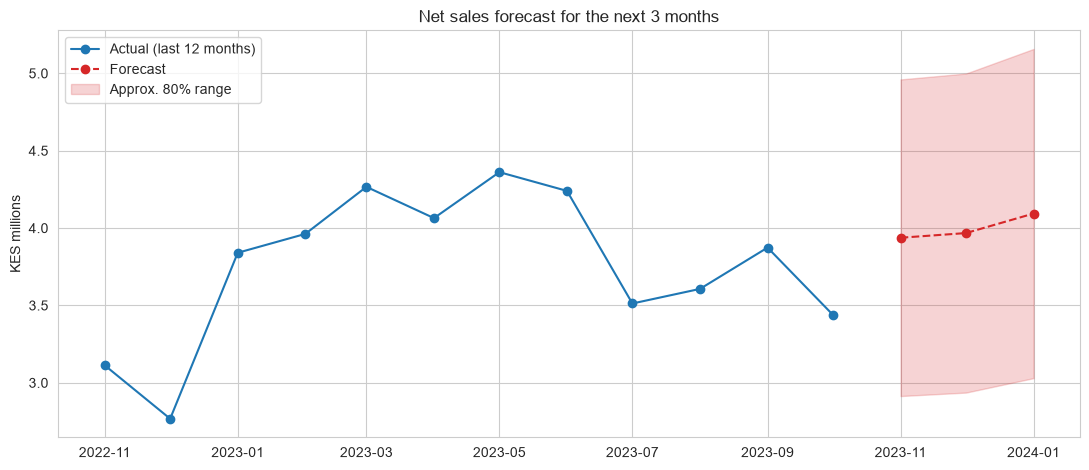

In [62]:
report = forecast_table.copy()
report.index = report.index.strftime("%b %Y")
report_kes = (report / 1e6).round(2).rename(columns={"forecast": "Forecast (KES m)", "lower": "Low (KES m)", "upper": "High (KES m)"})
report_kes.index.name = "Month"

report_kes.to_csv(ARTIFACT_DIR / "forecast_next_3_months.csv")
category_forecast.assign(Total_core_categories=category_forecast.sum(axis=1)).round(0).to_csv(ARTIFACT_DIR / "category_forecast_next_3_months.csv")

print("Net sales forecast, " + ", ".join(report.index))
print(f"Model: {selected_model} | accuracy status: WAPE {wape_status}, baseline improvement {improvement_status}")
print("Approximate 80% range, based on past validation errors; not a guarantee.\n")
display(report_kes)

fig, ax = plt.subplots(figsize=(11, 4.8))
recent = full_series.iloc[-12:]
ax.plot(recent.index, recent / 1e6, marker="o", label="Actual (last 12 months)")
ax.plot(forecast_table.index, forecast_table["forecast"] / 1e6, marker="o", ls="--", color="tab:red", label="Forecast")
ax.fill_between(forecast_table.index, forecast_table["lower"] / 1e6, forecast_table["upper"] / 1e6, alpha=0.2, color="tab:red", label="Approx. 80% range")
ax.set(title="Net sales forecast for the next 3 months", ylabel="KES millions", xlabel="")
ax.legend(); plt.tight_layout()
fig.savefig(ARTIFACT_DIR / "forecast_chart.png", dpi=150)
plt.show()

produces the three-month forecast table (in KES millions, with low and high values), the category forecast table and a chart, and saves them to the `artifacts` folder.

### 6.4 Using the Forecasts for Inventory and Cash-Flow Planning

The table below turns the forecast into planning figures: how each forecast month compares with the last actual month and with the same month a year earlier, and whether each core category is expected to sell more or less over the next three months than over the last three months.

In [63]:
last_actual = full_series.iloc[-1]
same_month_ly = full_series.reindex(forecast_table.index - pd.DateOffset(years=1)).to_numpy()

plan = forecast_table.copy()
plan["vs last actual month (%)"] = (plan["forecast"] / last_actual - 1) * 100
plan["vs same month last year (%)"] = (plan["forecast"].to_numpy() / same_month_ly - 1) * 100
display(plan.round(1))

# Category outlook: next 3 months versus the last 3 observed months (seasonal effects are not separated).
last3 = forecast_cat_wide[core_categories].iloc[-3:].sum()
next3 = category_forecast[core_categories].sum()
cat_outlook = pd.DataFrame({"Last 3 months (KES m)": last3 / 1e6, "Next 3 months forecast (KES m)": next3 / 1e6})
cat_outlook["Change (%)"] = (next3 / last3 - 1) * 100
cat_outlook["Outlook"] = np.where(cat_outlook["Change (%)"] > 0, "higher", "lower")
display(cat_outlook.round(2))

,forecast,lower,upper,vs last actual month (%),vs same month last year (%)
month,,,,,
2023-11-01,3937375.6,2914220.4,4960530.8,14.5,26.5
2023-12-01,3967566.9,2936566.2,4998567.5,15.4,43.4
2024-01-01,4093702.7,3029924.8,5157480.7,19.1,6.6


,Last 3 months (KES m),Next 3 months forecast (KES m),Change (%),Outlook
Baby Formula,7.97,8.63,8.23,higher
Bathing & Skin Care,0.45,0.49,8.28,higher
Feeding and weaning,0.83,1.09,32.39,higher
Baby Diapers,0.33,0.80,145.79,higher


**How a retailer can use this**

- **Purchasing and stock.** Use the central forecast as the base for supplier orders and the high value to decide how much extra to hold for fast-moving categories, especially formula, which is the largest category. Check the category outlook before ordering, and remember that category forecasts are separate and do not add up to the total.
- **Cash flow.** Budget cash inflows from the low value and stock purchases from the central value, so that a weak month does not cause a cash shortfall. The forecast covers revenue only. Margins, supplier terms and costs must be added by the retailer, since they are not in the data.
- **Review each month.** When a month closes, compare actual sales with the forecast, and adjust orders if sales are running outside the range.
- **Stock-outs.** If an item ran out, recorded sales understate demand, and the forecast will too. Record stock-outs so that this can be taken into account.

### 6.5 Retraining, Monitoring and Limitations

**Retraining.** Add each month's sales once the month is complete, then rerun the notebook or call `forecast_next_months` with the extended history. A partial month must not be used, because it would pull the forecast down. Re-run the model selection in Section 4 at least once a year, or sooner if accuracy drops, since new data may favour a different model.

**Monitoring.** Compare each forecast with what actually happened. The helper below uses the same WAPE and the same 15% limit as the success criterion. A trailing three-month WAPE above the limit, or errors that keep the same sign for several months, should trigger a review of the data and the model.

**Limitations.** The model is built on 36 months of history with strong growth and no external drivers. It does not anticipate promotions, price changes, stock-outs, holidays or changes in the sales channels. The forecast range is approximate. Forecasts should be treated as a planning aid with a safety margin, not as a commitment.

In [64]:
def monitor_forecast(actual, forecast, wape_limit=WAPE_TARGET):
    """Compare actual sales with earlier forecasts. REVIEW means WAPE is above the success-criterion limit."""
    w = wape_percent(actual, forecast)
    bias_kes = float(np.mean(np.asarray(actual, dtype=float) - np.asarray(forecast, dtype=float)))
    return {"months": len(actual), "WAPE (%)": round(float(w), 2), "mean error (KES)": round(bias_kes),
            "status": "OK" if w <= wape_limit else "REVIEW"}

# Demonstration on the held-out months (a real check would use new months as they close).
print(monitor_forecast(test, test_forecasts[selected_model]))

{'months': 3, 'WAPE (%)': 5.57, 'mean error (KES)': 136337, 'status': 'OK'}


defines a monitoring check and demonstrates it on the test months. It is a helper for later use and does not run on a schedule.